In [392]:
%load_ext autoreload
%autoreload 2


from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

import sys
sys.path.append('../src/')
sys.path.append('../tests/')


from utils import *
from Instance import *
from Solution import *
from metaheuristic_approach import *


from copy import deepcopy
from time import time


##### MILP MODEL #####
import gurobipy as gp
from gurobipy import GRB

from first_model import *



# fonction de validation des chromosomes
from validator_metaheuristique import (
    validate_best_chromosomes,
    print_validation_summary,
)

#fonction de validation des solutions MILP
from validator_model import (
    solve_and_validate_model,
    validate_model_solutions,
    print_validation_summary,
    validate_model_solution,
)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [326]:
TIME_DAY = 42 # 42 unités de temps = 1 journée de travail soit 7h

time_type_of_jobs = {
    "small": (3, 9),
    "medium": (9, 18),
    "long": (18, 42)
}

# I. Instance

Seed aléatoire pour l'instance : 4926
set
[{3, 4, 11, 15, 18, 23, 26, 27, 31, 33, 34, 39, 40, 44, 45, 46, 50, 51, 54, 55, 58, 61, 66, 73, 74}, {0, 1, 2, 5, 6, 7, 8, 10, 14, 17, 19, 20, 22, 24, 25, 29, 30, 35, 36, 38, 42, 48, 49, 52, 57, 60, 63, 65, 67, 69, 75}, {9, 12, 13, 16, 21, 28, 32, 37, 41, 43, 47, 53, 56, 59, 62, 64, 68, 70, 71, 72, 76}]
ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


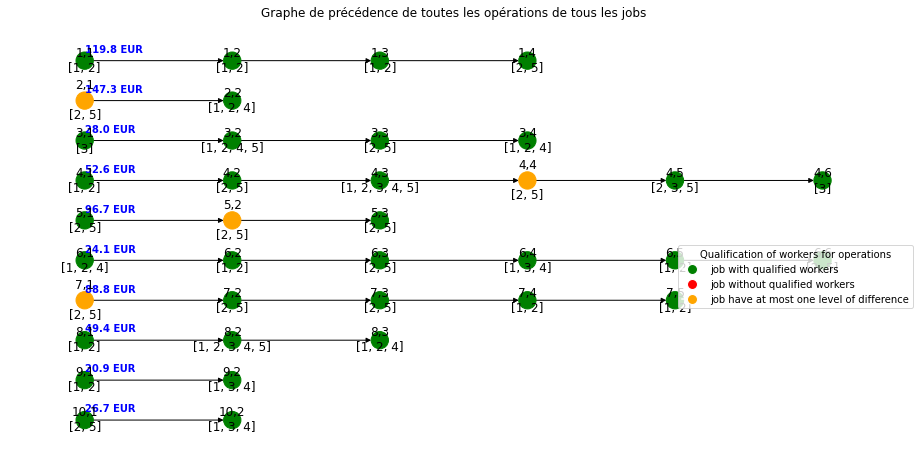

In [330]:
seed = np.random.randint(0, 10000)
print(f"Seed aléatoire pour l'instance : {seed}")
seed = 5083
config_instance = {
    "seed": seed,

    "nb_jobs": 10,
    "nb_workers": 5,
    "nb_professions": 5,
    "proportion_tasks_per_profession": [0.2, 0.2, 0.2, 0.2, 0.2], # [profession 1, profession 2, profession 3, profession 4, profession 5]
    "max_nb_operations": 7,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.1, 0.4, 0.4], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.3, 0.3, 0.1, 0.1], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": False
}

instance = Instance()
instance.from_config(config_instance)

visualization_before_scheduling(instance, not_qualified=True)

In [331]:
instance.visualize_jobs_overview()

## difference de level entre workers et opération

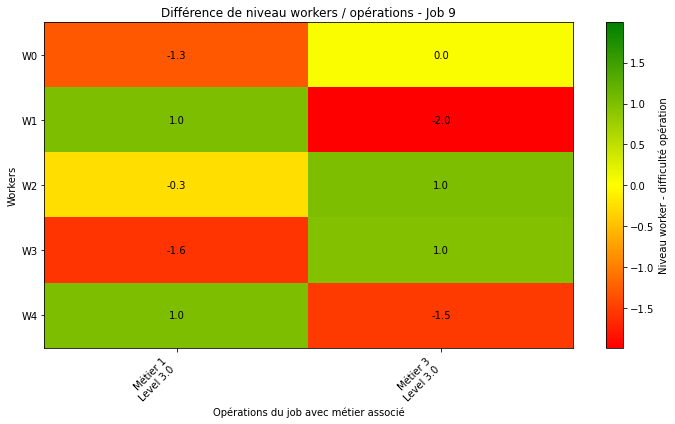

array([[-1.30282351,  0.03843107],
       [ 1.        , -1.9925392 ],
       [-0.26325202,  1.        ],
       [-1.58507198,  0.97370452],
       [ 1.        , -1.5401874 ]])

In [347]:
# for i in range(len(instance.jobs_struct)):
#     instance.vizualize_differences_levels_workers_job_i(i)

instance.vizualize_differences_levels_workers_job_i(9)

## Level des workers par métier

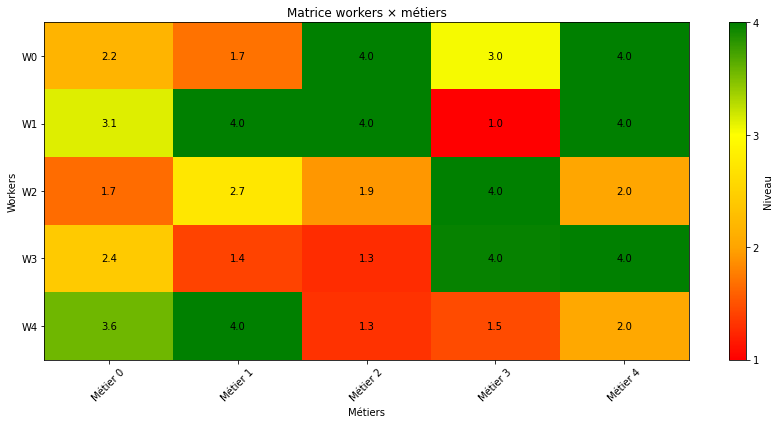

In [333]:
instance.vizualize_levels_workers()

In [460]:
constraints_config_baseline = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                 }

constraints_config_solo_no_level = {"job_with_no_skills": 1,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                 }

constraints_config_no_base_worker = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : True,
                        "no_solo_tasks": False,
                 }

constraints_config_no_teaching = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                        "no_teaching_tasks": True,
                 }

constraints_config_no_duo = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                        "no_teaching_tasks": False,
                        "all_solo_tasks" : True,
                 }
              

weights = {
    "profit" : 1,
    "skills" : 1,
    "cognitive_load" : 1
    }

# Lancement de toutes les configurations des sénario de contraintes différente

In [461]:
print("Lancement de toutes les configurations des sénario de contraintes différente")
print("Lancement du scénario baseline")
model_baseline = Model(instance)
s_baseline = model_baseline.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config_baseline, verbose=False)

print("Lancement du scénario solo_no_level")
model_solo_no_level = Model(instance)
s_solo_no_level = model_solo_no_level.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config_solo_no_level, verbose=False)

print("Lancement du scénario no_base_worker")
model_no_base_worker = Model(instance)
s_no_base_worker = model_no_base_worker.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config_no_base_worker, verbose=False)

print("Lancement du scénario no_teaching")
model_no_teaching = Model(instance)
s_no_teaching = model_no_teaching.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config_no_teaching, verbose=False)

print("Lancement du scénario no_duo")
model_no_duo = Model(instance)
s_no_duo = model_no_duo.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config_no_duo, verbose=False)

Lancement de toutes les configurations des sénario de contraintes différente
Lancement du scénario baseline

 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
nb_job_with_no_skills =  0
limite MAKESPAN =  20
constrained makespan activated with limit = 20
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 20
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 114.2212205633064
nObjectives 3
nSolutions 10
et la -> 20
Borne sup makespan: 20
Lancement du scénario solo_no_level

 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills activated
nb_job_with_no_skills =  1
limite MAKESPAN =  20
constrained makespan activated with limit = 20
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 20
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found 

In [462]:
list_solutions = [s_baseline, s_solo_no_level, s_no_base_worker, s_no_teaching, s_no_duo]
list_constraints_config = [constraints_config_baseline, constraints_config_solo_no_level, constraints_config_no_base_worker, constraints_config_no_teaching, constraints_config_no_duo]

In [463]:
for sss in list_solutions:
    print(sss._resale_price_job_done_plus_task_done(ponderation_task_done="one"))

114.2212205633064
258.74711407505623
168.09969169339996
86.3083145787026
84.3083145787026


In [471]:
for i in range(len(list_solutions)):
    row, ok = validate_model_solution(
        instance=instance,
        solution=list_solutions[i],
        constraints_config=list_constraints_config[i],
    )
    display(pd.DataFrame([row]))

validate_model_solutions(instance=instance, solutions=list_solutions, constraint_configs=list_constraints_config)

Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,114.221221,100.221221,1.5,41.110026,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=1
Exécution du test base_worker...
Exécution du test solo_no_level_difference...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,solo_no_level_difference,OK
0,solution,20.0,258.747114,241.747114,1.969434,37.035251,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test need_level_if_solo...


...

,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,no_teaching_tasks,need_level_if_solo,OK
0,solution,20.0,86.308315,70.308315,1.421085e-14,32.307967,PASS,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,84.308315,70.308315,1.421085e-14,0.0,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Exécution du test solution_valide...
nb_job_no_skills=1
Exécution du test base_worker...
Exécution du test solo_no_level_difference...
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test need_level_if_solo...
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test no_teaching_tasks...
Exécution du test need_level_if_solo...
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


(          Nom  C_max      Profit  Profit_job_done    Skill_gain  \
 0  solution_0   20.0  114.221221       100.221221  1.500000e+00   
 1  solution_1   20.0  258.747114       241.747114  1.969434e+00   
 2  solution_2   20.0  168.099692       149.099692 -4.263256e-14   
 3  solution_3   20.0   86.308315        70.308315  1.421085e-14   
 4  solution_4   20.0   84.308315        70.308315  1.421085e-14   
 
    Cognitive_load solution_valide base_worker need_level_if_solo    OK  \
 0       41.110026            PASS        PASS               PASS  TRUE   
 1       37.035251            PASS        PASS                NaN  TRUE   
 2       26.427342            PASS         NaN               PASS  TRUE   
 3       32.307967            PASS        PASS               PASS  TRUE   
 4        0.000000            PASS        PASS               PASS  TRUE   
 
   solo_no_level_difference no_teaching_tasks  
 0                      NaN               NaN  
 1                     PASS               

In [ ]:
print("Prix de revente des jobs terminés:")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_resale_price_job_done())

print("\nNombre de tasks terminées:")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_tasks_done())

print("\nNombre de jobs terminés:")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_jobs_done())

print("\nNombre de jobs commencés mais pas terminés:")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_jobs_beginned_but_not_done())

print("\nNiveau de compétence des travailleurs:")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_sum_skill_levels_rate())

print("\nCharge cognitive totale:")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_sum_cognitive_load_total())

print("\n Nombre d'opération fait en solo")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_tasks_done_solo())

print("\n Nombre d'opération fait en collab")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_tasks_done_collab())

print("\n Nombre d'opération fait en solo sans compétence")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_tasks_done_solo_no_level())

print("\n Nombre d'operation fait en teaching")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_tasks_done_teaching())

print("\n Nombre de jobs terminés avec au moins une tache faite en solo sans le niveau requis")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_jobs_done_with_some_task_done_solo_no_level(verbose=True))

print("\n Nombre de jobs avec au moins une tache faite en solo sans le niveau requis")
for i, s in enumerate(list_solutions):
    if s is not None:
        print("solution", i, ":", s.get_nb_jobs_with_some_task_done_solo_no_level(verbose=True))

print("\n Charge cognitive et id du worker qui a la charge cognitive la plus élevée")
for i, s in enumerate(list_solutions):
    if s is not None:
        worker_id, cognitive_load = s.get_cognitive_load_of_workers_highest()
        print("solution", i, ":", f"W{worker_id}: {cognitive_load}")


print()

Prix de revente des jobs terminés:
solution 0 : 100.2212205633064
solution 1 : 241.74711407505623
solution 2 : 149.09969169339996
solution 3 : 70.3083145787026

Nombre de tasks terminées:
solution 0 : 14.0
solution 1 : 17.0
solution 2 : 19.0
solution 3 : 16.0

Nombre de jobs terminés:
solution 0 : 3
solution 1 : 4
solution 2 : 5
solution 3 : 2

Nombre de jobs commencés mais pas terminés:
solution 0 : 2
solution 1 : 3
solution 2 : 2
solution 3 : 6

Niveau de compétence des travailleurs:
solution 0 : 1.4999999999999574
solution 1 : 1.96943417160999
solution 2 : -4.263256414560601e-14
solution 3 : 1.4210854715202004e-14

Charge cognitive totale:
solution 0 : 41.11002607140483
solution 1 : 37.03525074968189
solution 2 : 26.427341787458133
solution 3 : 32.307966579202365

 Nombre d'opération fait en solo
solution 0 : 7.0
solution 1 : 9.0
solution 2 : 14.0
solution 3 : 10.0

 Nombre d'opération fait en collab
solution 0 : 4.0
solution 1 : 3.0
solution 2 : 5.0
solution 3 : 6.0

 Nombre d'opér

In [472]:
labels = ["baseline",
    "solo_no_level",
    "no_base_worker",
    "no_teaching",
    "no_duo"
]
dfs = Solution.solutions_to_df(list_solutions, labels)

In [473]:
dfs

,resale_price,nb_jobs_done,nb_jobs_started_not_done,nb_tasks_done,nb_tasks_solo,nb_tasks_teaching,nb_tasks_collab,nb_tasks_solo_no_level,nb_jobs_done_with_no_level,nb_jobs_any_no_level,skill_gain,cognitive_load_total,cognitive_load_max_worker,worker_max_tasks,nb_max_tasks,worker_min_tasks,nb_min_tasks
label,,,,,,,,,,,,,,,,,
baseline,100.221221,3,2,14.0,7.0,3.0,4.0,0.0,0,0,1.500000e+00,41.110026,5.7,1,7.0,2,2.0
solo_no_level,241.747114,4,3,17.0,9.0,3.0,3.0,2.0,1,1,1.969434e+00,37.035251,5.0,1,7.0,3,3.0
no_base_worker,149.099692,5,2,19.0,14.0,0.0,5.0,0.0,0,0,-4.263256e-14,26.427342,5.2,1,7.0,2,3.0
no_teaching,70.308315,2,6,16.0,10.0,0.0,6.0,0.0,0,0,1.421085e-14,32.307967,5.8,1,8.0,2,1.0
no_duo,70.308315,2,6,14.0,14.0,0.0,0.0,0.0,0,0,1.421085e-14,0.000000,0.0,0,6.0,3,0.0


In [478]:
import matplotlib.pyplot as plt
import numpy as np


def plot_metrics_heatmap(df, save_path=None):
    labels = df.index.tolist()

    metric_names = [name.replace("\n", " ") for name, _, _ in RADAR_METRICS]

    values = []

    for _, col, direction in RADAR_METRICS:
        normalized = _normalize(df[col].values.astype(float), direction)
        values.append(normalized)

    # lignes = solutions
    # colonnes = métriques
    matrix = np.array(values).T

    fig, ax = plt.subplots(
        figsize=(2.2 * len(metric_names), 1.2 * len(labels) + 2)
    )

    im = ax.imshow(
        matrix,
        aspect="auto",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(range(len(metric_names)))
    ax.set_xticklabels(
        metric_names,
        rotation=30,
        ha="right",
        fontsize=11
    )

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(
        labels,
        fontsize=12
    )

    # Valeurs normalisées dans les cases
    for i in range(len(labels)):
        for j in range(len(metric_names)):
            value = matrix[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

    ax.set_title(
        "Comparaison normalisée des solutions",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(
        "Score normalisé (1 = meilleur)",
        fontsize=11
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return fig

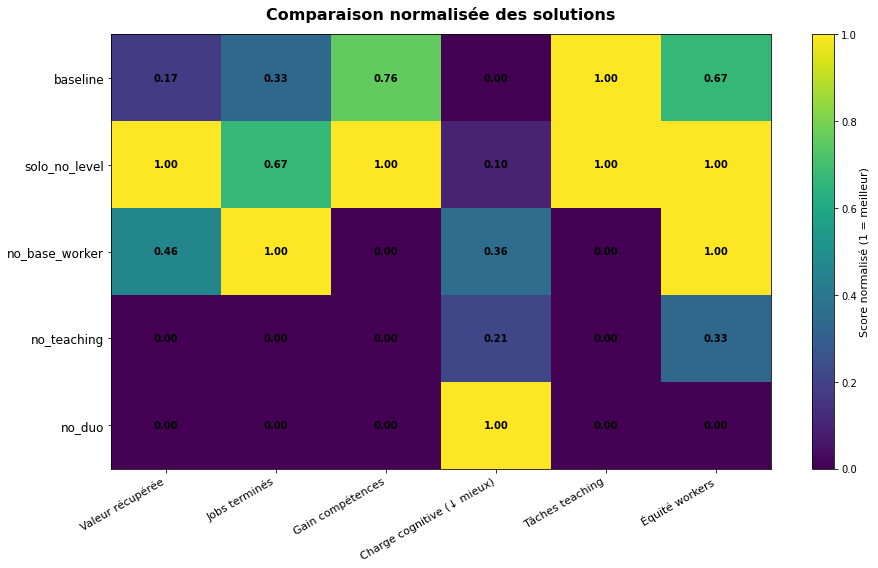

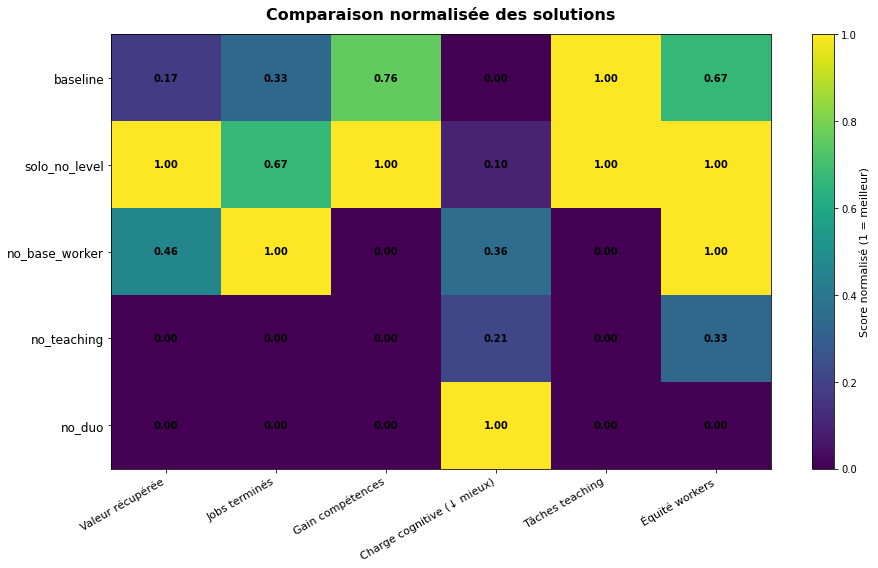

In [479]:
plot_metrics_heatmap(dfs, save_path=None)

In [476]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# ── Configuration ────────────────────────────────────────────────────────────
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
MARKERS = ["o", "s", "D", "^", "v"]

# Métriques du radar : (label affiché, colonne df, sens: +1 = plus grand = mieux, -1 = plus petit = mieux)
RADAR_METRICS = [
    ("Valeur\nrécupérée",       "resale_price",           +1),
    ("Jobs\nterminés",          "nb_jobs_done",            +1),
    ("Gain\ncompétences",       "skill_gain",              +1),
    ("Charge cognitive\n(↓ mieux)", "cognitive_load_total", -1),
    ("Tâches\nteaching",        "nb_tasks_teaching",       +1),
    ("Équité\nworkers",         "nb_min_tasks",            +1),
]

# Groupes pour les dot plots
DOT_GROUPS = [
    ("Économique", [
        ("Prix de revente",                 "resale_price"),
        ("Jobs terminés",                   "nb_jobs_done"),
        ("Commencés / non terminés",        "nb_jobs_started_not_done"),
    ]),
    ("Modes d'exécution", [
        ("Solo",                            "nb_tasks_solo"),
        ("Teaching",                        "nb_tasks_teaching"),
        ("Collaboration",                   "nb_tasks_collab"),
        ("Solo sans niveau",                "nb_tasks_solo_no_level"),
    ]),
    ("Objectifs", [
        ("Gain compétences",                "skill_gain"),
        ("Charge cognitive totale",         "cognitive_load_total"),
        ("Charge cognitive max worker",     "cognitive_load_max_worker"),
    ]),
]


def _normalize(vals, direction):
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return np.ones_like(vals) * 0.5
    normed = (vals - mn) / (mx - mn)
    return normed if direction == +1 else 1 - normed


# ── Radar chart ───────────────────────────────────────────────────────────────
def plot_radar(df, title="Comparaison des scénarios", save_path=None):
    labels  = df.index.tolist()
    n_ax    = len(RADAR_METRICS)
    angles  = np.linspace(0, 2 * np.pi, n_ax, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")

    # Grille
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=11, color="#888888")
    ax.set_ylim(0, 1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [m[0] for m in RADAR_METRICS],
        fontsize=13, fontweight="bold", color="#333333"
    )
    ax.tick_params(axis="x", pad=18)
    ax.spines["polar"].set_color("#cccccc")
    ax.grid(color="#cccccc", linestyle="--", linewidth=0.8)

    for s_idx, label in enumerate(labels):
        vals = np.array([
            _normalize(df[col].values, direction)[s_idx]
            for _, col, direction in RADAR_METRICS
        ])
        vals = np.concatenate([vals, vals[:1]])
        color = COLORS[s_idx % len(COLORS)]
        ax.plot(angles, vals, color=color, linewidth=2.5, linestyle="-", marker=MARKERS[s_idx % len(MARKERS)], markersize=9)
        ax.fill(angles, vals, color=color, alpha=0.12)

    legend_handles = [
        mpatches.Patch(color=COLORS[i % len(COLORS)], label=lbl)
        for i, lbl in enumerate(labels)
    ]
    ax.legend(handles=legend_handles, loc="upper right",
              bbox_to_anchor=(1.35, 1.15), fontsize=13,
              framealpha=0.8, edgecolor="#cccccc")

    ax.set_title(title, fontsize=17, fontweight="bold", pad=28, color="#222222")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


# ── Dot plots ─────────────────────────────────────────────────────────────────
# ── Dot plots : une figure par métrique ───────────────────────────────────────
def plot_dot_metrics(df, save_dir=None):
    labels = df.index.tolist()
    figures = []

    for group_name, metrics in DOT_GROUPS:
        for metric_name, col in metrics:

            fig, ax = plt.subplots(figsize=(10, 4.5))
            fig.patch.set_facecolor("#FAFAFA")
            ax.set_facecolor("#FAFAFA")

            vals = df[col].values

            # Ligne horizontale
            ax.axhline(
                0,
                color="#e0e0e0",
                linewidth=1.0,
                zorder=0
            )

            # Points des différentes solutions
            for s_idx, (val, lbl) in enumerate(zip(vals, labels)):
                color = COLORS[s_idx % len(COLORS)]
                marker = MARKERS[s_idx % len(MARKERS)]

                ax.scatter(
                    val,
                    0,
                    color=color,
                    marker=marker,
                    s=180,
                    zorder=3,
                    label=lbl
                )

                # Valeur affichée au-dessus du point
                ax.text(
                    val,
                    0.10,
                    f"{val:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    color=color,
                    fontweight="bold"
                )

            # Axe Y inutile puisqu'on affiche une seule métrique
            ax.set_yticks([])
            ax.set_ylim(-0.35, 0.45)

            ax.set_xlabel("Valeur", fontsize=12)

            ax.set_title(
                f"{group_name} — {metric_name}",
                fontsize=15,
                fontweight="bold",
                pad=15,
                color="#222222"
            )

            ax.spines[["top", "right", "left"]].set_visible(False)

            ax.tick_params(
                axis="x",
                labelsize=11
            )

            # Légende placée à droite du graphique
            ax.legend(
                loc="center left",
                bbox_to_anchor=(1.02, 0.5),
                fontsize=11,
                framealpha=0.8,
                edgecolor="#cccccc"
            )

            # Laisse de la place pour la légende
            plt.tight_layout(rect=[0, 0, 0.82, 1])

            # Sauvegarde : une image par métrique
            if save_dir:
                import os

                os.makedirs(save_dir, exist_ok=True)

                filename = (
                    col
                    .replace("/", "_")
                    .replace(" ", "_")
                    + ".png"
                )

                path = os.path.join(save_dir, filename)

                fig.savefig(
                    path,
                    dpi=300,
                    bbox_inches="tight"
                )

            plt.show()

            figures.append(fig)

    return figures

# ── Entrée principale ─────────────────────────────────────────────────────────
def plot_solutions_df(
    df,
    save_radar=None,
    save_dots_dir=None
):
    fig_radar = plot_radar(
        df,
        save_path=save_radar
    )

    fig_dots = plot_dot_metrics(
        df,
        save_dir=save_dots_dir
    )

    return fig_radar, fig_dots


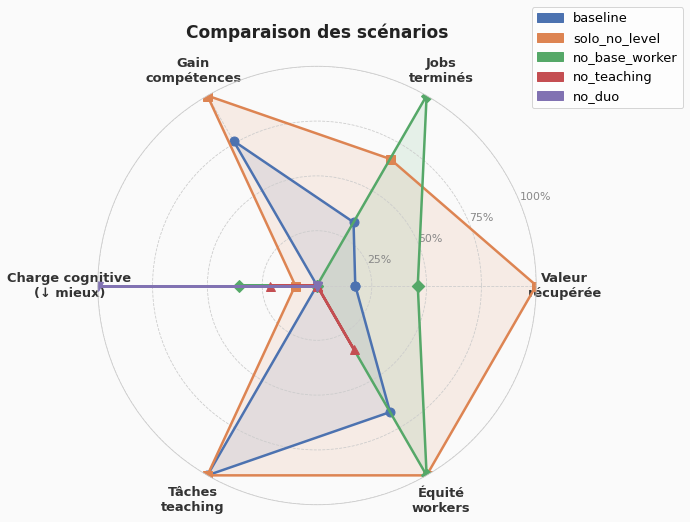

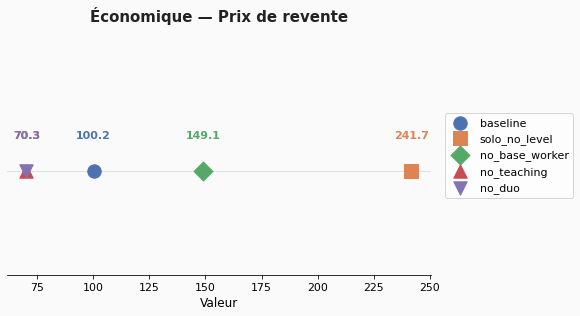

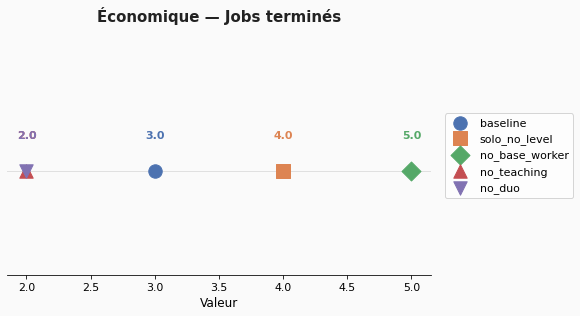

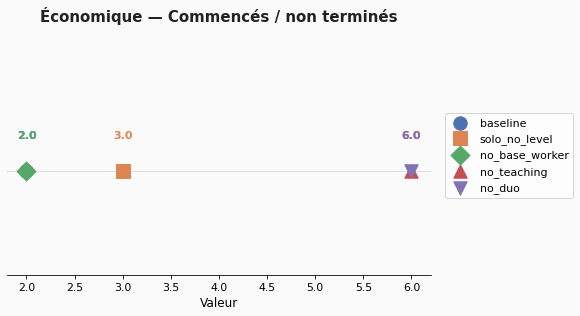

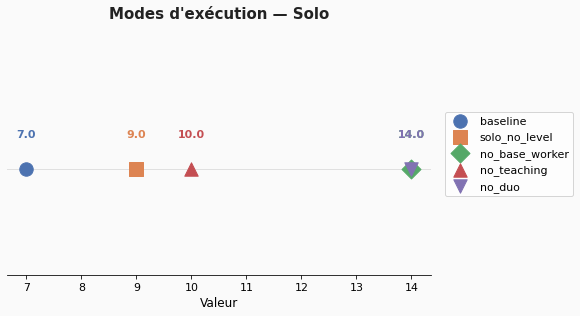

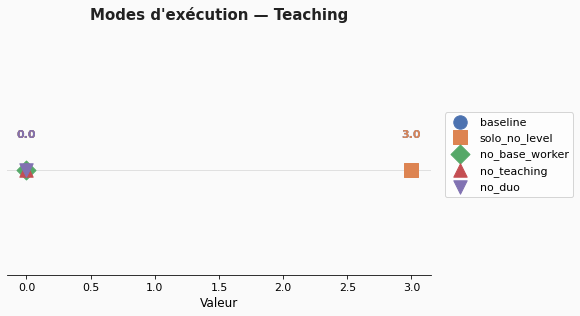

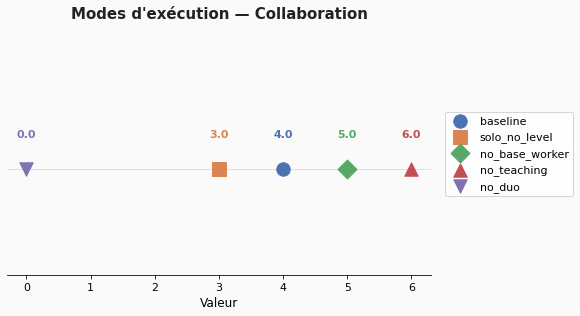

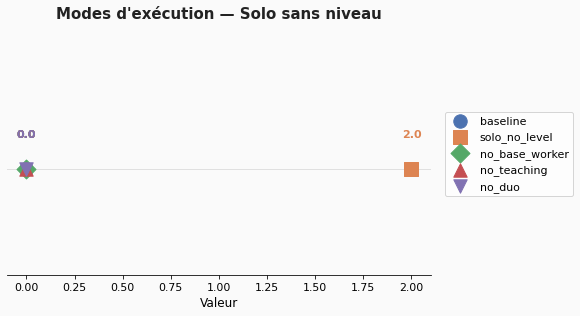

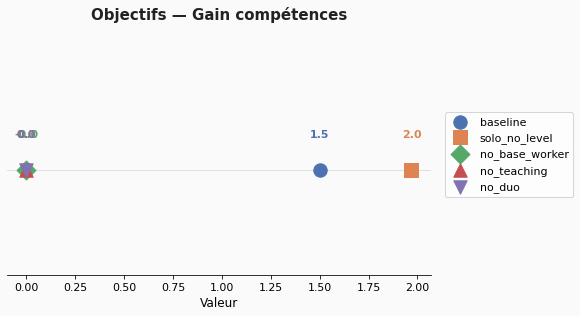

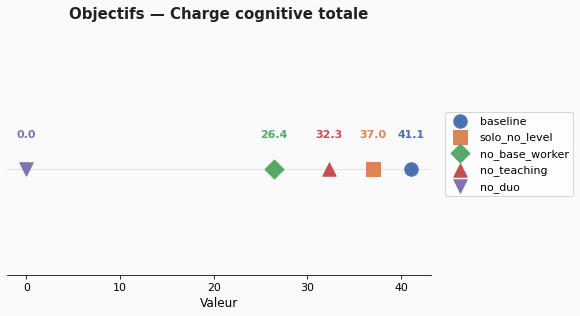

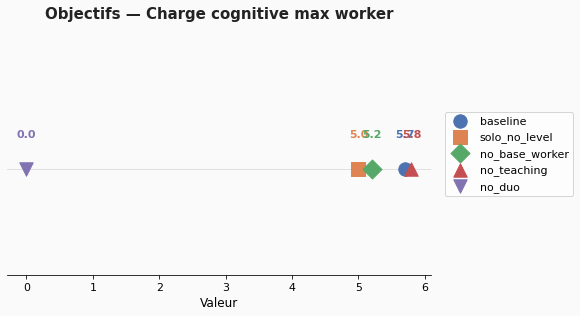

(<Figure size 720x720 with 1 Axes>,
 [<Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>,
  <Figure size 720x324 with 1 Axes>])

In [477]:
plot_solutions_df(dfs)

## A) MILP

In [ ]:
modelprime = Model(instance)
sprime = model.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)


 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
limite MAKESPAN =  20
constrained makespan activated with limit = 20
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 20
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 114.2212205633064
nObjectives 3
nSolutions 10
et la -> 20
Borne sup makespan: 20


In [ ]:
row, ok = validate_model_solution(
    instance=instance,
    solution=sprime,
    constraints_config=constraints_config,
)
display(pd.DataFrame([row]))

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,114.221221,1.5,41.110026,PASS,PASS,PASS,TRUE


In [ ]:
model = Model(instance)
s = model.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)

model_no_teaching = Model(instance)
s_no_teaching = model_no_teaching.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config_no_teaching, verbose=False)


 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
limite MAKESPAN =  20
constrained makespan activated with limit = 20
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 20
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 114.2212205633064
nObjectives 3
nSolutions 10
et la -> 20
Borne sup makespan: 20

 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
limite MAKESPAN =  20
constrained makespan activated with limit = 20
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 20
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 86.3083145787026
nObjectives 3
nSolutions 10
et la -> 20
Borne sup makespan: 20


In [ ]:
df = scheduling_to_df(s, instance)
df_no_teaching = scheduling_to_df(s_no_teaching, instance)

In [ ]:
print("Solution with all modes:")
s.print_objective_values()
print()
print("Solution with no teaching tasks:")
s_no_teaching.print_objective_values()

Solution with all modes:
Objective values:
Obj0: 114.2212205633064
Obj1: 1.499999999999944
Obj2: -41.11002607140483

Solution with no teaching tasks:
Objective values:
Obj0: 86.3083145787026
Obj1: 4.440892098500626e-15
Obj2: -32.30796657920236


In [ ]:
check_df(df)
check_df(df_no_teaching)

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
df_grouped=
   Operation                   mode  count
0      (1,1)                  alone      1
1     (10,1)  learning (apprentice)      1
2     (10,1)       learning (tutor)      1
3     (10,2)        collaboratively      2
4      (4,1)                  alone      1
5      (6,1)        collaboratively      2
6      (6,2)        collaboratively      2
7      (6,3)                  alone      1
8      (6,4)  learning (apprentice)      1
9      (6,4)       learning (tutor)      1
10     (6,5)                  alone      1
11     (6,6)        collaboratively      2
12     (8,1)                  alone      1
13     (8,2)                  alone      1
14     (8,3)  learning (apprentice)      1
15     (8,3)       learning (tutor)      1
16     (9,1)                  alone      1
All conditions are satisfied for the Gantt chart.
 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
df_grouped=
   Operation             mode  c

True

In [ ]:
row, ok = validate_model_solution(
    instance=instance,
    solution=s,
    constraints_config=constraints_config,
)
display(pd.DataFrame([row]))

row_no_teaching, ok_no_teaching = validate_model_solution(
    instance=instance,
    solution=s_no_teaching,
    constraints_config=constraints_config_no_teaching,
)
display(pd.DataFrame([row_no_teaching]))

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,114.221221,1.5,41.110026,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test no_teaching_tasks...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,no_teaching_tasks,need_level_if_solo,OK
0,solution,20.0,86.308315,1.421085e-14,32.307967,PASS,PASS,PASS,PASS,TRUE


In [ ]:
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Job_done,Elementary task,Metier
0,w1,0.106261,1.540318,1.540318,1.434057,"(1,1)",J1,alone,4.000000,2.0,False,44.0,2.0
1,w1,1.540318,3.805764,3.805764,2.265446,"(6,2)",J6,collaboratively,4.000000,3.0,True,31.0,2.0
2,w1,3.805764,9.962531,9.962531,6.156768,"(8,1)",J8,alone,4.000000,4.0,True,38.0,2.0
3,w1,9.962531,13.149736,13.149736,3.187204,"(8,2)",J8,alone,2.175527,1.0,True,3.0,0.0
4,w1,13.149736,17.648743,17.648743,4.499007,"(9,1)",J9,alone,4.000000,2.0,False,42.0,2.0
5,w1,17.648743,19.638421,19.638421,1.989678,"(8,3)",J8,learning (tutor),4.000000,3.0,True,73.0,4.0
6,w2,0.000000,1.540318,1.540318,1.540318,"(6,1)",J6,collaboratively,4.000000,3.0,True,61.0,4.0
7,w2,1.540318,3.805764,3.805764,2.265446,"(6,2)",J6,collaboratively,4.000000,3.0,True,31.0,2.0
8,w2,3.805764,7.155802,7.155802,3.350038,"(6,3)",J6,alone,4.000000,4.0,True,23.0,1.0
9,w2,7.155802,13.327508,13.327508,6.171705,"(6,4)",J6,learning (apprentice),1.007461,2.0,True,55.0,3.0


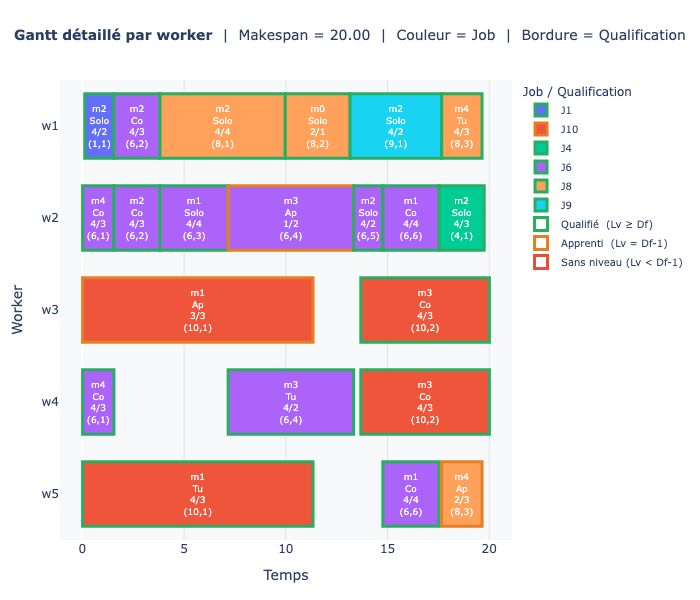

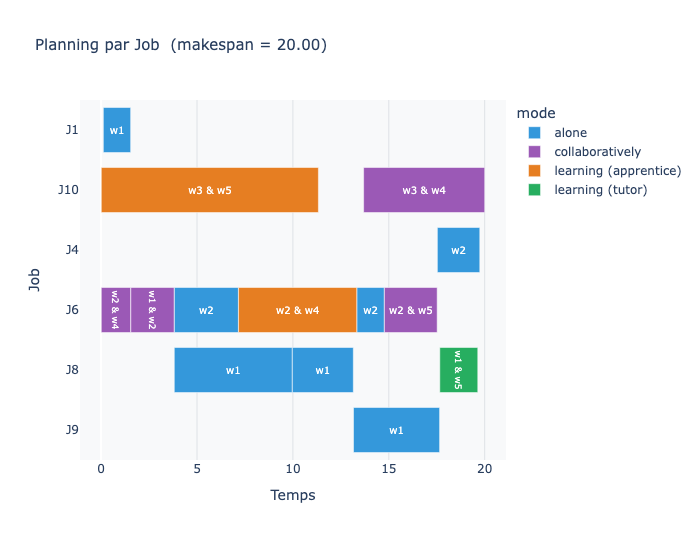

In [ ]:
gantt_chart_rich(df, render="notebook", save_path=None)
gantt_chart_by_job(df, instance, color_by="mode", render="notebook", save_path=None, separate_little=True)

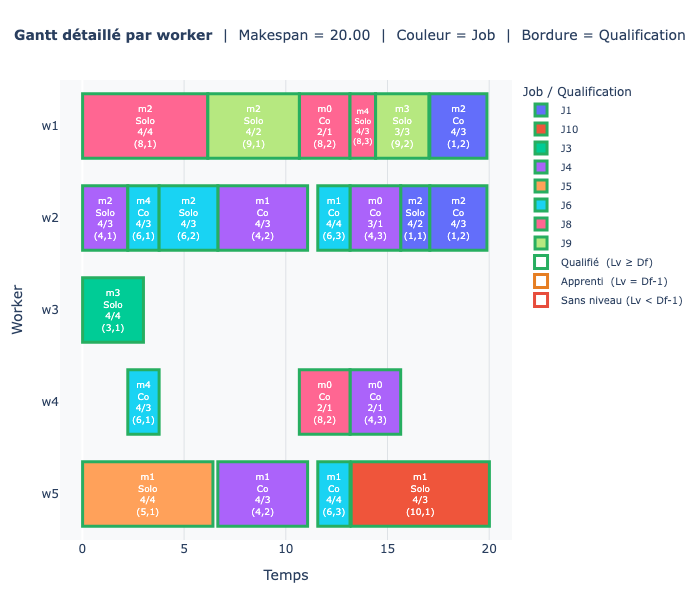

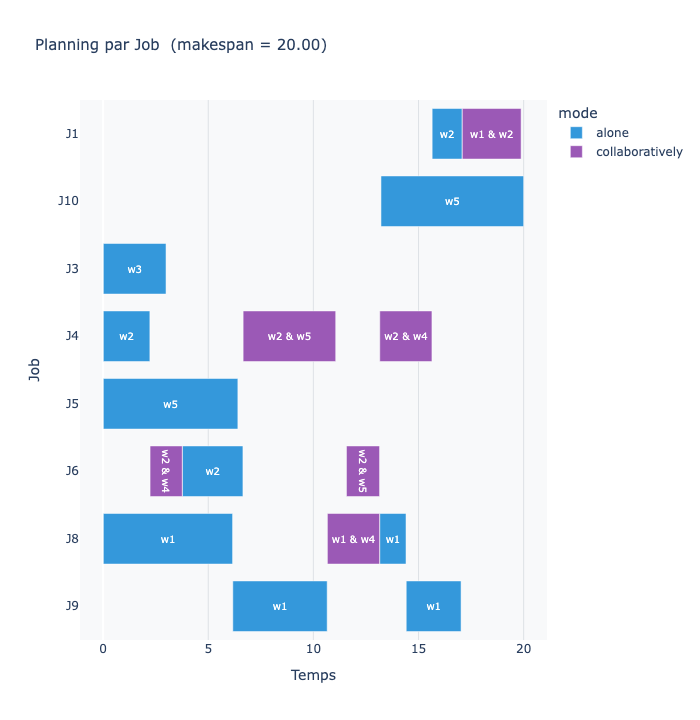

In [ ]:
gantt_chart_rich(df_no_teaching, render="notebook", save_path=None)
gantt_chart_by_job(df_no_teaching, instance, color_by="mode", render="notebook", save_path=None, separate_little=True)

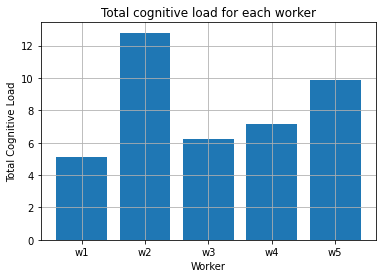

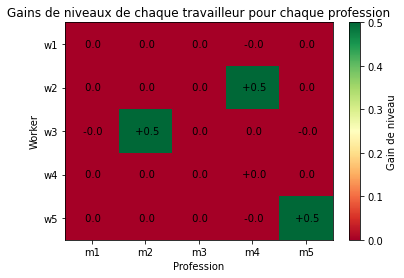

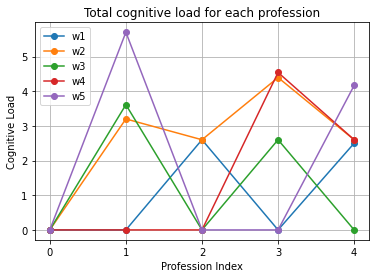

In [ ]:
bars_cognitive_load_total(s, instance)
resume_levels_workers(s, instance)
plot_cognitive_load_total(s, instance)

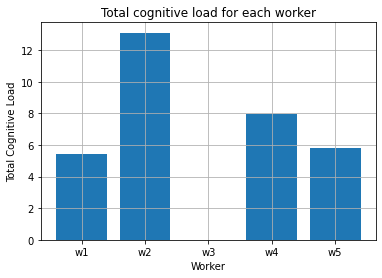

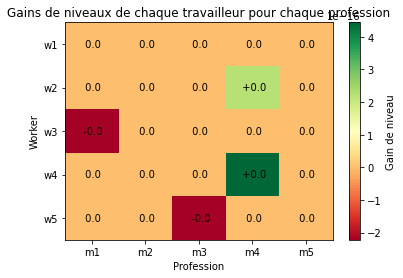

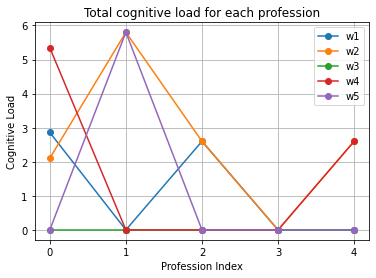

In [ ]:
bars_cognitive_load_total(s_no_teaching, instance)
resume_levels_workers(s_no_teaching, instance)
plot_cognitive_load_total(s_no_teaching, instance)

In [ ]:
s_report = solution_business_report(s, instance)
plot_business_report(s_report, instance)


═══════════════════════════════════════════════════════
  RAPPORT BUSINESS — SOLUTION MILP
═══════════════════════════════════════════════════════

──────────────────── FINANCIER ────────────────────
  Jobs terminés   : 3/10  (30%)
  CA réalisé      : 100.2 EUR  /  potentiel 654.3 EUR  (15%)
  Makespan        : 20.00

────────────────── AVANCEMENT DES JOBS ─────────────
  Terminés  (3/10) : J6 J8 J10
  En cours  (3/10) :
  J1  [█████░░░░░░░░░░░░░░░] 1/4 ops  (17% diff.)  restant ≈23.0u
       Faites    : Op1✓
       Restantes : Op2⬜  Op3⬜  Op4⬜
  J4  [███░░░░░░░░░░░░░░░░░] 1/6 ops  (18% diff.)  restant ≈28.2u
       Faites    : Op1✓
       Restantes : Op2⬜  Op3⬜  Op4⬜  Op5⬜  Op6⬜
  J9  [██████████░░░░░░░░░░] 1/2 ops  (40% diff.)  restant ≈2.6u
       Faites    : Op1✓
       Restantes : Op2⬜
  Backlog total estimé : 53.9 unités de temps
  Non commencés (4/10) : J2 J3 J5 J7

────────────────── OCCUPATION WORKERS ──────────────
  w1  occ=98%  ops=6  CL=5.1  [Solo:4  Tu:1  Co:1]
  w2  occ

In [ ]:
s_report_no_teaching = solution_business_report(s_no_teaching, instance)
plot_business_report(s_report_no_teaching, instance)


═══════════════════════════════════════════════════════
  RAPPORT BUSINESS — SOLUTION MILP
═══════════════════════════════════════════════════════

──────────────────── FINANCIER ────────────────────
  Jobs terminés   : 2/10  (20%)
  CA réalisé      : 70.3 EUR  /  potentiel 654.3 EUR  (11%)
  Makespan        : 20.00

────────────────── AVANCEMENT DES JOBS ─────────────
  Terminés  (2/10) : J8 J9
  En cours  (6/10) :
  J1  [██████████░░░░░░░░░░] 2/4 ops  (42% diff.)  restant ≈18.3u
       Faites    : Op1✓  Op2✓
       Restantes : Op3⬜  Op4⬜
  J3  [█████░░░░░░░░░░░░░░░] 1/4 ops  (31% diff.)  restant ≈24.4u
       Faites    : Op1✓
       Restantes : Op2⬜  Op3⬜  Op4⬜
  J4  [██████████░░░░░░░░░░] 3/6 ops  (41% diff.)  restant ≈18.2u
       Faites    : Op1✓  Op2✓  Op3✓
       Restantes : Op4⬜  Op5⬜  Op6⬜
  J5  [██████░░░░░░░░░░░░░░] 1/3 ops  (33% diff.)  restant ≈13.6u
       Faites    : Op1✓
       Restantes : Op2⬜  Op3⬜
  J6  [██████████░░░░░░░░░░] 3/6 ops  (56% diff.)  restant ≈11.6u
   

In [ ]:
s_summary = s.get_summary("All modes")
s_summary_no_teaching = s_no_teaching.get_summary("No teaching")

In [ ]:
Solution.plot_comparison([s_summary, s_summary_no_teaching])

In [ ]:
sum([s.job_done[i] * instance.resale_price_jobs[i] for i in range(instance.nb_jobs)])

100.2212205633064

In [ ]:
sum([s_no_teaching.job_done[i] * instance.resale_price_jobs[i] for i in range(instance.nb_jobs)])

70.3083145787026

In [ ]:
s_summary, s_summary_no_teaching

({'label': 'All modes',
  'nb_jobs_total': 10,
  'nb_jobs_done': 3,
  'nb_ops_total': 37,
  'nb_ops_done': 14,
  'mode_solo': 7,
  'mode_teaching': 3,
  'mode_collab': 4,
  'mode_solo_no_level': 0,
  'nb_ops_production': 11,
  'nb_ops_formation': 3,
  'nb_ops_with_level': 14,
  'nb_ops_without_level': 0,
  'total_penalty_levels': 0.0,
  'benefit': 114.2212205633064,
  'skill_gain': 1.4999999999999574,
  'cognitive_load': 41.11002607140483},
 {'label': 'No teaching',
  'nb_jobs_total': 10,
  'nb_jobs_done': 2,
  'nb_ops_total': 37,
  'nb_ops_done': 16,
  'mode_solo': 10,
  'mode_teaching': 0,
  'mode_collab': 6,
  'mode_solo_no_level': 0,
  'nb_ops_production': 16,
  'nb_ops_formation': 0,
  'nb_ops_with_level': 16,
  'nb_ops_without_level': 0,
  'total_penalty_levels': 0.0,
  'benefit': 86.3083145787026,
  'skill_gain': 1.4210854715202004e-14,
  'cognitive_load': 32.307966579202365})

## B) Local Search

In [ ]:
ONE_NB_SEED = 5
ONE_MAX_ITER = 200

enc   = Encoding_Dicos(instance)
gen   = ChromosomeGenerator(instance, enc, constraints_config=constraints_config)
dec   = Decoder(instance, enc, constraints_config=constraints_config)
eval  = Evaluator(dec, weights)
sel   = BestSelector()


In [ ]:
random_search = RandomSearch(gen, eval)

In [ ]:
all, best, iter = random_search.run(500, verbose=True)

iter 0: New best fitness: 34.55050954009782
iter 25: New best fitness: 45.414985514665844
iter 99: New best fitness: 60.04596337306056
iter 121: New best fitness: 60.66369743440639


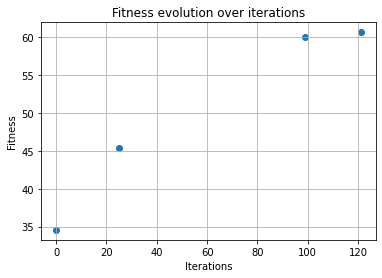

In [ ]:
y = []

for i in range (len(best)):
    y.append(best[i].fitness)

plt.scatter(iter, y)
plt.title("Fitness evolution over iterations")
plt.xlabel("Iterations")
plt.ylabel("Fitness")
plt.grid()
plt.show()

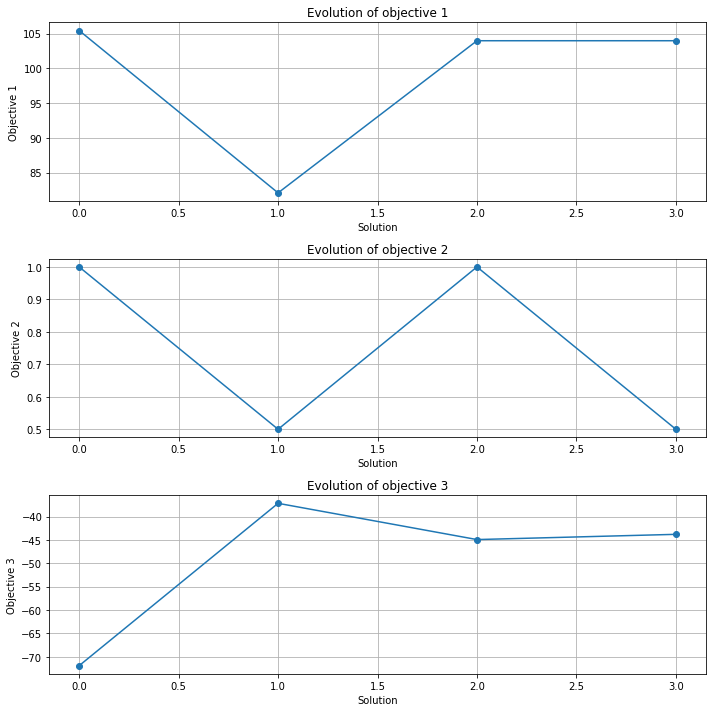

In [ ]:
random_search.plot_each_objectives()

In [ ]:
for i in range(len(best)):
    s_rs = dec.decode_solution(best[i])
    row, ok = validate_model_solution(
    instance=instance,
    solution=s_rs,
    constraints_config=constraints_config,
    )
    display(pd.DataFrame([row]))

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,105.439243,1.0,71.888733,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,82.090292,0.5,37.175307,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,103.970774,1.0,44.92481,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,103.970774,0.5,43.807076,PASS,PASS,PASS,TRUE


In [ ]:
s_rs = dec.decode_solution(best[-1])
df_rs = scheduling_to_df(s_rs, instance)

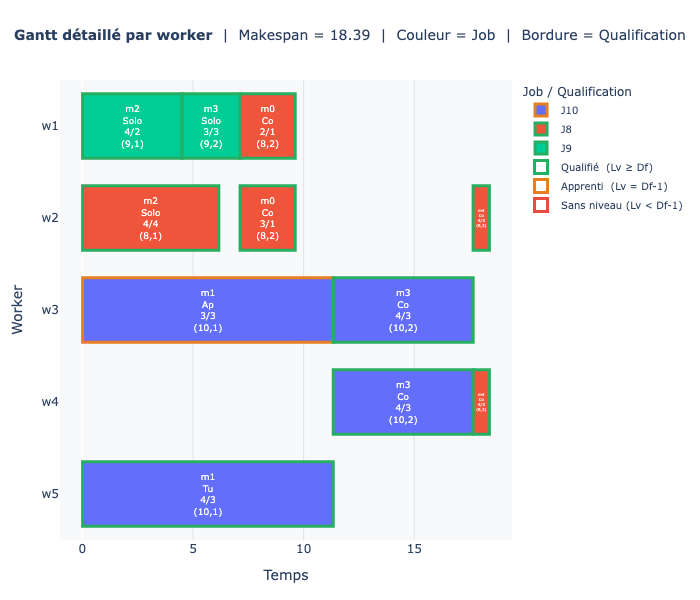

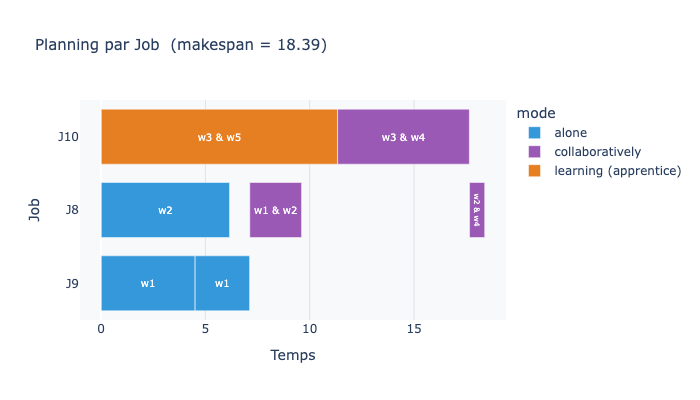

In [ ]:
gantt_chart_rich(df_rs, render="notebook", save_path=None)
gantt_chart_by_job(df_rs, instance, color_by="mode", render="notebook", save_path=None, separate_little=True)

In [ ]:
s_report_rs = solution_business_report(s_rs, instance)
plot_business_report(s_report_rs, instance)


═══════════════════════════════════════════════════════
  RAPPORT BUSINESS — SOLUTION MILP
═══════════════════════════════════════════════════════

──────────────────── FINANCIER ────────────────────
  Jobs terminés   : 3/10  (30%)
  CA réalisé      : 97.0 EUR  /  potentiel 654.3 EUR  (15%)
  Makespan        : 20.00

────────────────── AVANCEMENT DES JOBS ─────────────
  Terminés  (3/10) : J8 J9 J10
  Non commencés (7/10) : J1 J2 J3 J4 J5 J6 J7

────────────────── OCCUPATION WORKERS ──────────────
  w1  occ=48%  ops=3  CL=7.9  [Solo:2  Co:1]
  w2  occ=47%  ops=3  CL=7.8  [Solo:1  Co:2]
  w3  occ=88%  ops=2  CL=6.2  [Ap:1  Co:1]
  w4  occ=35%  ops=2  CL=5.2  [Co:2]
  w5  occ=57%  ops=1  CL=16.6  [Tu:1]

────────────────── GAINS DE COMPÉTENCES ────────────
  w3  m2:+0.5
  Gain total : +0.50

────────────────── QUALITÉ ─────────────────────────
  ✓ Toutes les opérations respectent les niveaux requis.
═══════════════════════════════════════════════════════



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# diff.shape = (nb_jobs, 2, nb_max_operations)
# base_workers.shape = (2, nb_jobs)
# x_ijk.shape = (nb_jobs, nb_max_operations, nb_workers)

def plot_worker_diff(diff, base_workers, x_ijk):
    nb_jobs, _, nb_ops = diff.shape

    values = np.full((nb_jobs, nb_ops), np.nan)
    labels = np.empty((nb_jobs, nb_ops), dtype=object)

    for i in range(nb_jobs):
        w_base = base_workers[0, i]
        has_penalty = base_workers[1, i]

        for j in range(nb_ops):
            assigned_workers = np.where(x_ijk[i, j, :] == 1)[0]

            if diff[i, 0, j] == -100:
                labels[i, j] = "op inexist."
                continue

            txt = f"Base W{w_base}"
            if has_penalty == 1:
                txt += " penal."

            txt += "\n"

            if len(assigned_workers) == 0:
                txt += "non affecté"
                values[i, j] = -99

            else:
                vals = []
                for idx, w in enumerate(assigned_workers[:2]):
                    v = diff[i, idx, j]
                    vals.append(f"W{w}: {v:.1f}")

                txt += "\n".join(vals)
                values[i, j] = np.nanmean([
                    diff[i, idx, j]
                    for idx in range(min(len(assigned_workers), 2))
                    if diff[i, idx, j] not in [-99, -100]
                ])

            labels[i, j] = txt

    plt.figure(figsize=(14, 8))

    ax = sns.heatmap(
        values,
        annot=labels,
        fmt="",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
        linecolor="black",
        cbar_kws={"label": "Différence worker / opération"}
    )

    ax.set_xlabel("Opération")
    ax.set_ylabel("Job")
    ax.set_title("Worker de base, workers affectés et différence")

    ax.set_xticklabels([f"op {j}" for j in range(nb_ops)])
    ax.set_yticklabels([f"job {i}" for i in range(nb_jobs)], rotation=0)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm



def plot_jobs_heatmap(mat, title="Différence worker / opération"):
    """
    mat shape: (nb_job, 2, nb_max_operations)

    Valeurs:
      -100 : opération inexistante
      -99  : opération non affectée
      autre: différence entre niveau worker et niveau opération
    """

    nb_job, nb_workers, nb_max_operations = mat.shape

    assert nb_workers == 2, "La deuxième dimension doit être de taille 2"

    # On transforme en matrice 2D :
    # lignes = job0-worker0, job0-worker1, job1-worker0, ...
    H = mat.reshape(nb_job * 2, nb_max_operations)

    special_missing_op = H == -100
    special_not_assigned = H == -99
    valid = ~(special_missing_op | special_not_assigned)

    # Valeurs réelles seulement
    H_valid = H.astype(float)
    H_valid[~valid] = np.nan

    fig, ax = plt.subplots(figsize=(max(8, nb_max_operations * 0.6), max(5, nb_job * 0.5)))

    # Fond blanc pour opérations inexistantes
    background = np.ones((*H.shape, 4))
    background[special_missing_op] = [1, 1, 1, 1]        # blanc
    background[special_not_assigned] = [0.75, 0.75, 0.75, 1]  # gris
    background[valid] = [1, 1, 1, 0]  # transparent pour laisser passer la heatmap

    ax.imshow(background, aspect="auto")


    # # Heatmap des vraies valeurs
    # im = ax.imshow(H_valid, cmap="coolwarm", aspect="auto")


    cmap = plt.get_cmap("RdYlGn").copy()
    cmap.set_bad((1, 1, 1, 0))

    norm = TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4)

    im = ax.imshow(H_valid, cmap=cmap, norm=norm, aspect="auto")

    # Afficher les valeurs dans les cases
    for i in range(H.shape[0]):
        for k in range(H.shape[1]):

            if H[i, k] == -100:
                text = ""          # opération inexistante : rien
            elif H[i, k] == -99:
                text = "NA"        # non affecté
            else:
                text = f"{H[i, k]:.1f}"

            ax.text(
                k, i, text,
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

    # Axes
    ax.set_title(title)
    ax.set_xlabel("Opération")
    ax.set_ylabel("Job / Worker")

    ax.set_xticks(np.arange(nb_max_operations))
    ax.set_xticklabels([f"op {i}" for i in range(nb_max_operations)])

    y_labels = []
    for j in range(nb_job):
        y_labels.append(f"job {j} - wi")
        y_labels.append(f"job {j} - wj")

    ax.set_yticks(np.arange(nb_job * 2))
    ax.set_yticklabels(y_labels)

    # Séparateurs entre jobs
    for j in range(1, nb_job):
        ax.axhline(j * 2 - 0.5, color="black", linewidth=1)

    # Grille légère
    ax.set_xticks(np.arange(-0.5, nb_max_operations, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nb_job * 2, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar pour les différences valides
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Différence niveau worker - niveau opération")

    # Légende pour les valeurs spéciales
    legend_patches = [
        mpatches.Patch(color="lightgray", label="-99 : non affecté"),
        mpatches.Patch(color="white", label="-100 : opération inexistante"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.25, 1))

    plt.tight_layout()
    plt.show()

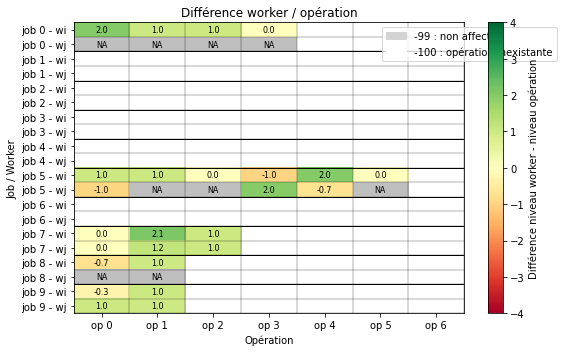

In [ ]:
duo_test = get_base_worker_operation(c.base_worker_assignment, s_meta_bis_bis.x, instance)
plot_jobs_heatmap(duo_test)

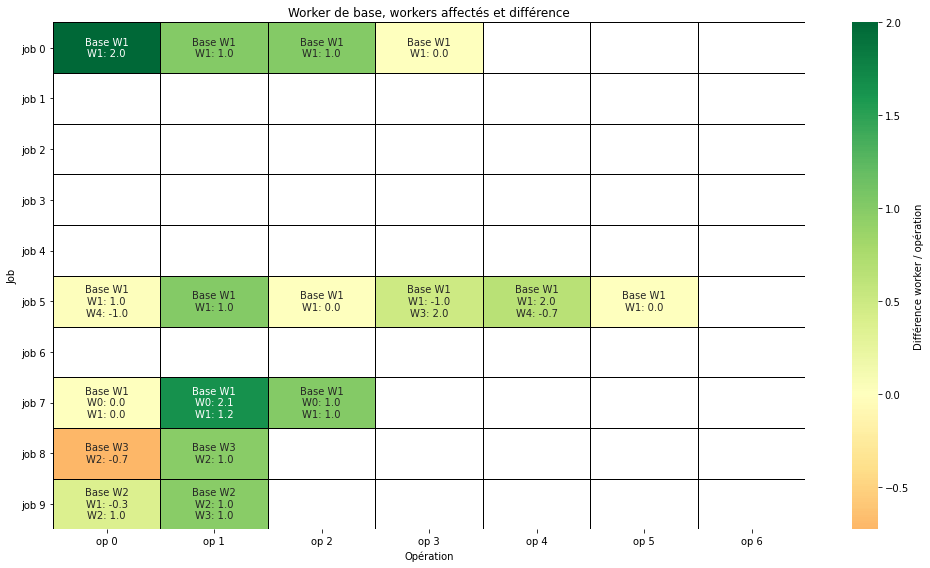

In [ ]:
plot_worker_diff(duo_test, c.base_worker_assignment, s_meta_bis_bis.x)

## C) Comparaison des voisinages — MultiNeighborhoodBenchmark

In [ ]:
NB_JOB_NO_SKILLS = constraints_config.get("nb_job_no_skills", 0)
print(f"NB_JOB_NO_SKILLS = {NB_JOB_NO_SKILLS}")
benchmark = MultiNeighborhoodBenchmark(
    generator=gen,
    evaluator=eval,
    neighborhoods=[
        (SwapOperationNeighborhood(n=10, nb_job_no_skills=NB_JOB_NO_SKILLS),                "Swap OSC"),
        (MoveOneOperationNeighborhood(),                                                    "Move OSC"),
        (MoveSecondWorkerNeighborhood(gen),                                                "Move SWAC"),
        (ChangebaseWorkerNeighborhood(nb_job_no_skills=NB_JOB_NO_SKILLS, generator=gen),   "Change Base Worker"),
        (multipleNeighborhood_alternating(
            SwapOperationNeighborhood(n=5, nb_job_no_skills=NB_JOB_NO_SKILLS),
            MoveSecondWorkerNeighborhood(gen),
            nb_job_no_skills=NB_JOB_NO_SKILLS
        ),                                                                                 "Alternating (Swap + SWAC)"),
    ],
    selector=BestSelector()
)

res = benchmark.run(max_iter=ONE_MAX_ITER, shared_start=True, verbose=True)

NB_JOB_NO_SKILLS = 0
Point de départ commun — fitness initiale : 23.5979

=== Voisinage : Swap OSC ===
Initial fitness: 23.597898174599003
iter 1: New best fitness: 29.85184081165022
iter 6: New best fitness: 34.05184081165022
iter 38: New best fitness: 38.63287622600478

=== Voisinage : Move OSC ===
Initial fitness: 23.597898174599003
iter 2: New best fitness: 34.05184081165022
iter 3: New best fitness: 38.63287622600478

=== Voisinage : Move SWAC ===
Initial fitness: 23.597898174599003
iter 1: New best fitness: 34.05184081165022
iter 4: New best fitness: 35.34474885390232
iter 18: New best fitness: 35.86170005179672
iter 105: New best fitness: 36.85155847238778

=== Voisinage : Change Base Worker ===
Initial fitness: 23.597898174599003
iter 1: New best fitness: 38.95747181384287
iter 2: New best fitness: 50.648720202556035
iter 5: New best fitness: 60.34830314675444
iter 64: New best fitness: 61.25169020337174
iter 66: New best fitness: 62.54459824562383
iter 167: New best fitness: 6

In [ ]:
print(res.keys())

dict_keys(['Swap OSC', 'Move OSC', 'Move SWAC', 'Change Base Worker', 'Alternating (Swap + SWAC)'])


In [ ]:
benchmark.plot_fitness_comparison()

In [ ]:
benchmark.validate_results(
    decoder=dec,
    instance=instance,
    constraints_config=constraints_config,
    validate_fn=validate_model_solution,
)


Voisinage : Swap OSC  |  fitness : 38.6329
Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,76.308315,0.0,37.675438,PASS,PASS,PASS,TRUE



Voisinage : Move OSC  |  fitness : 38.6329
Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,76.308315,0.0,37.675438,PASS,PASS,PASS,TRUE



Voisinage : Move SWAC  |  fitness : 36.8516
Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,77.308315,1.0,41.456756,PASS,PASS,PASS,TRUE



Voisinage : Change Base Worker  |  fitness : 62.7176
Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,103.970774,0.5,41.753134,PASS,PASS,PASS,TRUE



Voisinage : Alternating (Swap + SWAC)  |  fitness : 39.9258
Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20,76.308315,0.0,36.38253,PASS,PASS,PASS,TRUE


## Visu de change_base_worker

In [ ]:
cbw_chormosome = res["Change Base Worker"]["best_list"][-1]
cbw_solution = dec.decode_solution(cbw_chormosome)

In [ ]:
cbw_s_summary = cbw_solution.get_summary()
s_summary = s.get_summary()

In [ ]:
Solution.plot_comparison([cbw_s_summary, s_summary], title="Comparaison des solutions")

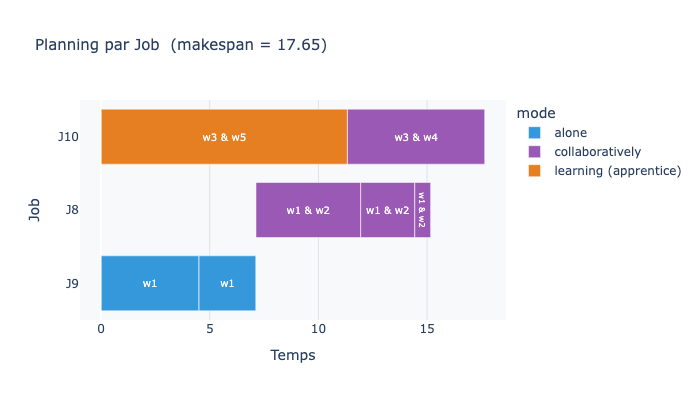

In [ ]:
df_cbw = scheduling_to_df(cbw_solution, instance)
gantt_chart_rich(df_cbw, render="notebook", save_path=None)
gantt_chart_by_job(df_cbw, instance, color_by="mode", render="notebook", save_path=None, separate_little=True)

In [ ]:
s_report_cbw = solution_business_report(cbw_solution, instance)
plot_business_report(s_report_cbw, instance)


═══════════════════════════════════════════════════════
  RAPPORT BUSINESS — SOLUTION MILP
═══════════════════════════════════════════════════════

──────────────────── FINANCIER ────────────────────
  Jobs terminés   : 3/10  (30%)
  CA réalisé      : 97.0 EUR  /  potentiel 654.3 EUR  (15%)
  Makespan        : 20.00

────────────────── AVANCEMENT DES JOBS ─────────────
  Terminés  (3/10) : J8 J9 J10
  Non commencés (7/10) : J1 J2 J3 J4 J5 J6 J7

────────────────── OCCUPATION WORKERS ──────────────
  w1  occ=76%  ops=5  CL=13.7  [Solo:2  Co:3]
  w2  occ=40%  ops=3  CL=7.9  [Co:3]
  w3  occ=88%  ops=2  CL=6.2  [Ap:1  Co:1]
  w4  occ=32%  ops=1  CL=2.6  [Co:1]
  w5  occ=57%  ops=1  CL=11.3  [Tu:1]

────────────────── GAINS DE COMPÉTENCES ────────────
  w3  m2:+0.5
  Gain total : +0.50

────────────────── QUALITÉ ─────────────────────────
  ✓ Toutes les opérations respectent les niveaux requis.
═══════════════════════════════════════════════════════



---

# II. Plusieurs instances

### Nombre d'instance à générer

In [ ]:
NB_INSTANCES = 5

### Seed pour la génération des instances

In [ ]:
instance_seed = []
for i in range(NB_INSTANCES):
    instance_seed.append(np.random.randint(1, 1000)) # pour générer un nombre aléatoire entre 1 et 1000 (inclus)
print(f"instance_seed: {instance_seed}")

instance_seed: [918, 159, 673, 759, 615]


### Génération des instances

In [ ]:
config_instances = []
for i in range(NB_INSTANCES):
    seed = instance_seed[i]
    config_instance = {
        "seed": seed,

        "nb_jobs": 5,
        "nb_workers": 3,
        "nb_professions": 1,
        "proportion_tasks_per_profession": [1], # [profession 1, profession 2]
        "max_nb_operations": 4,
        "nb_tasks" : "lower", # "lower", "medium", "high"

        # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

        "proportion_tasks_without_collaborative_work": 0.2,
        "proportion_tasks_level_required": 0.1,

        "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
        "time_type_of_jobs" : time_type_of_jobs,
        "proportion_tasks_levels":[ 0.1, 0.3, 0.4, 0.2], # [level 1, level 2, level 3, level 4]

        "proportion_workers_levels":[ 0.1, 0.2, 0.4, 0.3], # [level 1, level 2, level 3, level 4]

        "at_least_a_worker_have_competence_for_each_profession": False
    }
    config_instances.append(config_instance)

In [ ]:
instances = []
for i in range(NB_INSTANCES):
    instance = Instance()
    instance.from_config(config_instances[i])
    instances.append(instance)

set
[{1, 3, 7, 14, 17, 20, 21}, {2, 4, 5, 11, 12, 15}, {0, 6, 8, 9, 10, 13, 16, 18, 19}]
set
[{1, 7, 10, 15, 17, 18, 20, 21}, {2, 3, 5, 6, 8, 11, 13, 16, 19}, {0, 4, 9, 12, 14}]
set
[{0, 3, 4, 5, 7, 9, 15, 19, 21}, {2, 6, 8, 10, 12, 14}, {1, 11, 13, 16, 17, 18, 20}]
set
[{3, 11, 12, 13, 14, 17, 18}, {0, 4, 5, 6, 7, 8, 15, 16, 20, 21}, {1, 2, 9, 10, 19}]
set
[{1, 6, 8, 11, 13, 15}, {3, 4, 5, 7, 9, 14, 16, 19, 21}, {0, 2, 10, 12, 17, 18, 20}]


#### conversion des temps en int pour faciliter calcules et comparaisons

In [ ]:
# conversion des temps en int pour faciliter calcules et comparaisons
for instance in instances:
    instance.tasks_times = np.array(instance.tasks_times, dtype=int)

### Visualisation des instances générées

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


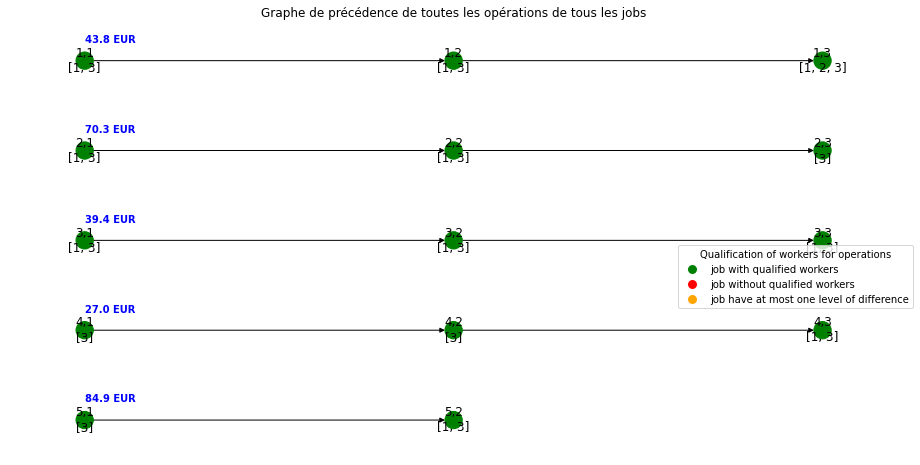

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


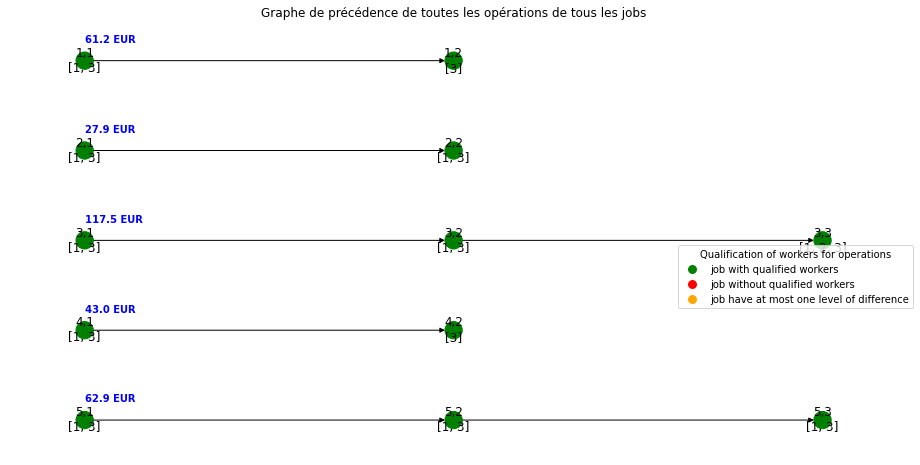

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


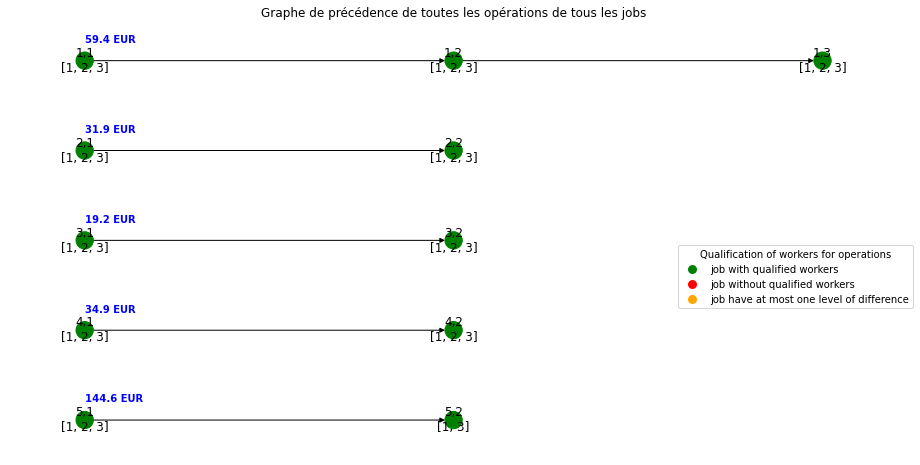

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


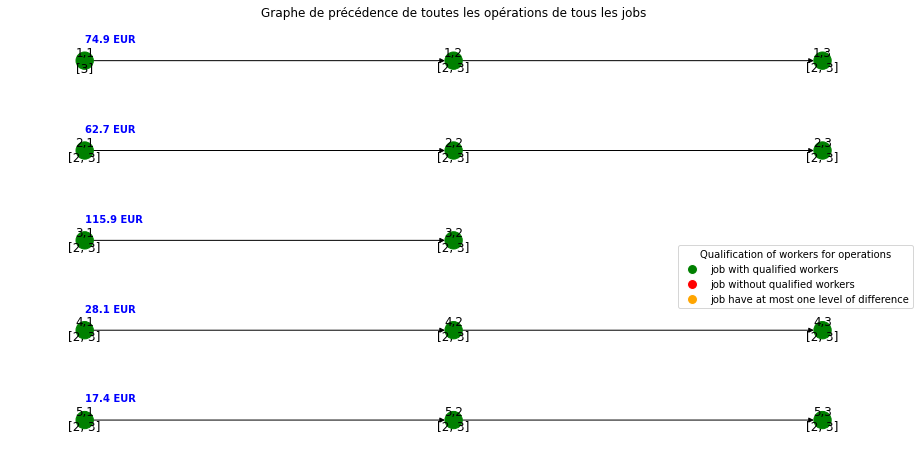

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


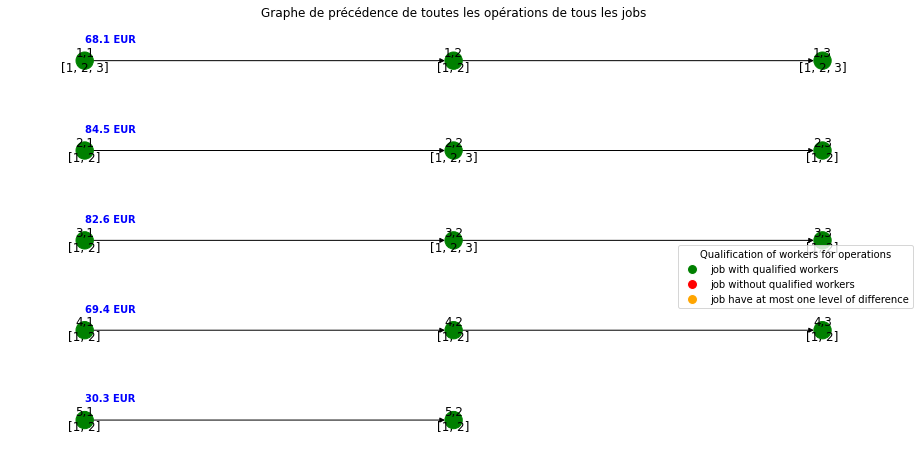

In [ ]:
for instance in instances:
    visualization_before_scheduling(instance, not_qualified=True)

---

---

## Comparaison optim profit VS 3 objectives

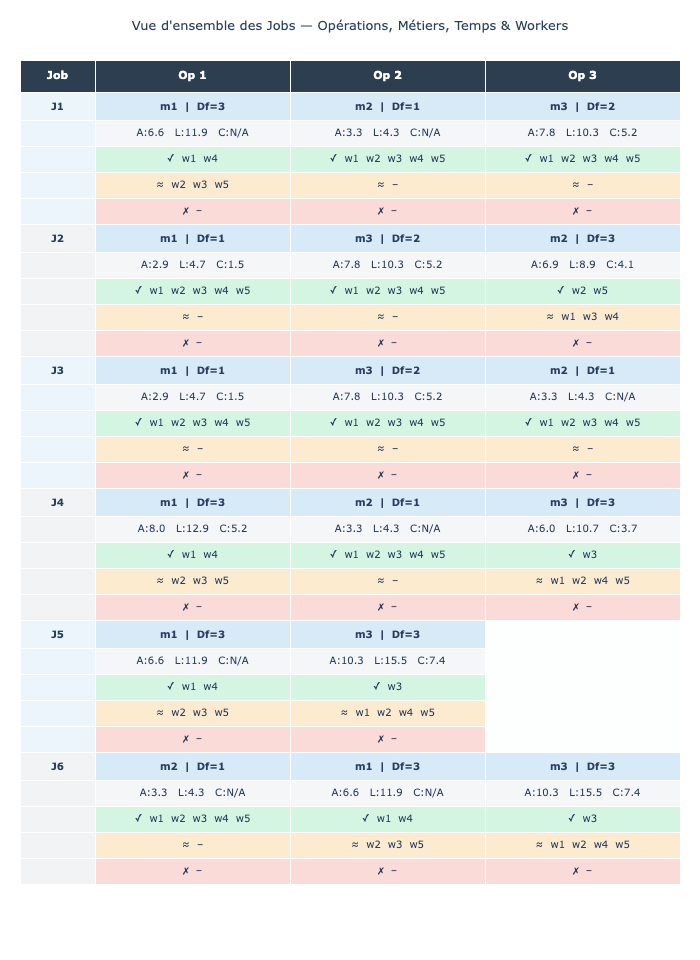

In [190]:
instance2 = Instance()
instance2.from_scenario(nb_jobs=6, 
                        nb_workers=5, 
                        nb_professions=3, 
                        nb_tasks_per_profession=3, 
                        max_nb_operations=4, 
                        worker_profile="balanced", 
                        schedule_tightness=0.8, 
                        seed=42
                        )

instance2.visualize_jobs_overview(render="notebook")

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


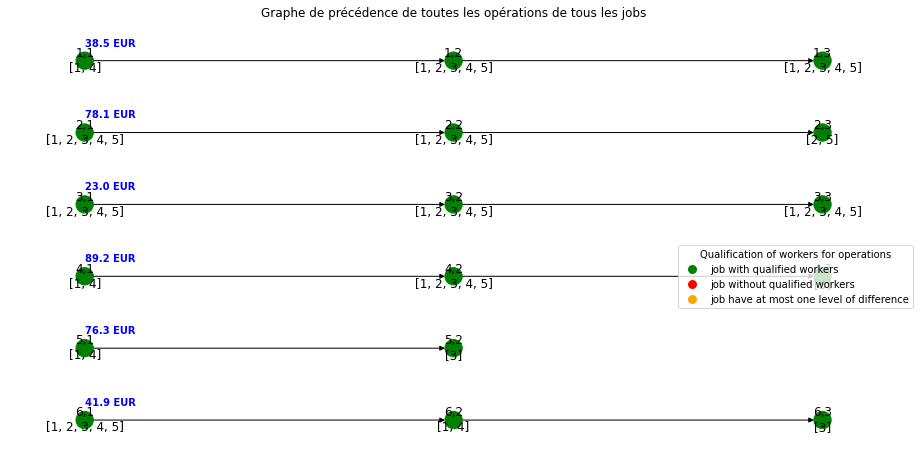

In [191]:
visualization_before_scheduling(instance2, not_qualified=True)

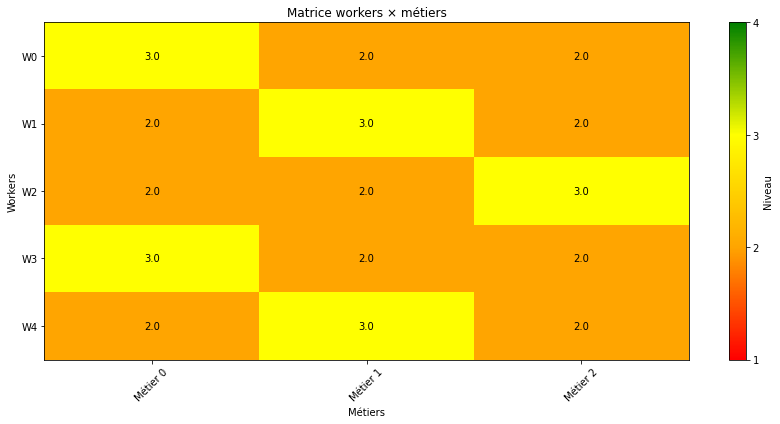

In [192]:
instance2.vizualize_levels_workers()

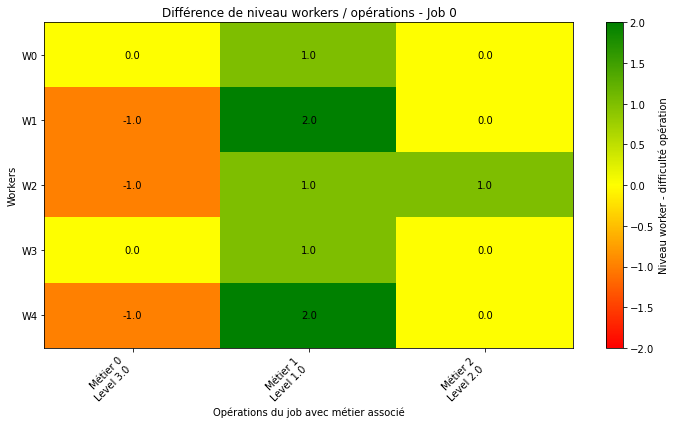

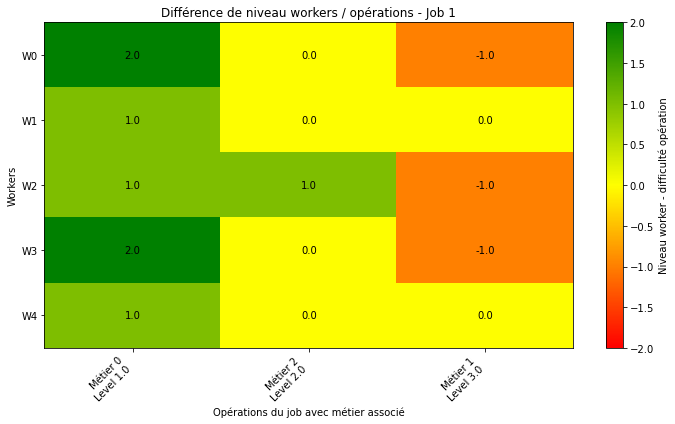

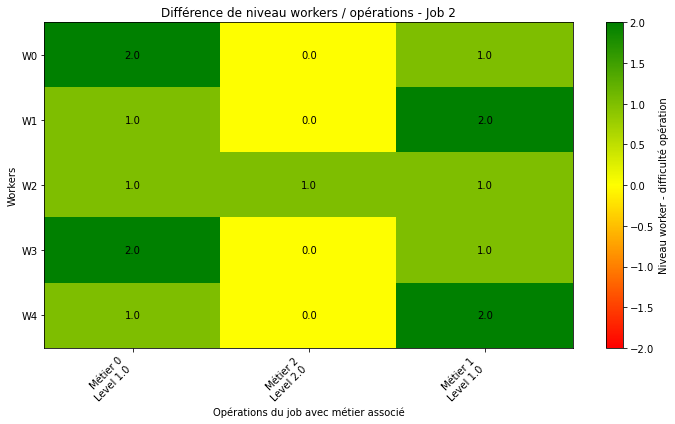

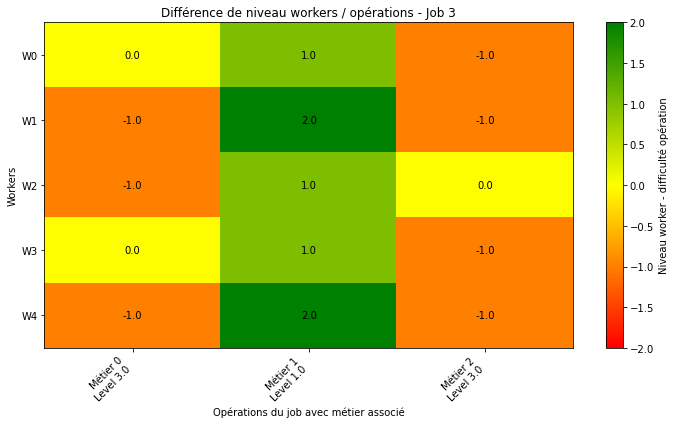

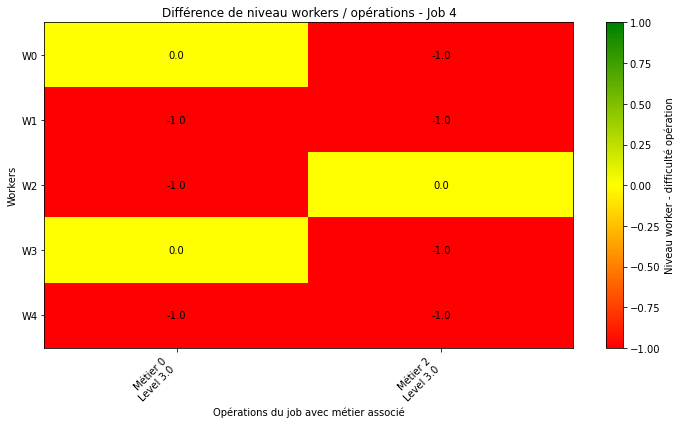

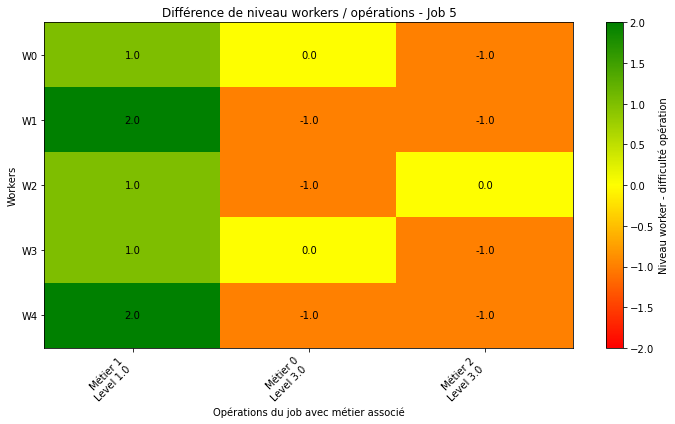

In [193]:
for i in range(len(instance2.jobs_struct)):
    instance2.vizualize_differences_levels_workers_job_i(i)

----

# benefit VS lex

## Optim du profit seul

In [198]:
constraints_config2 = {"job_with_no_skills": False,
                        "constrained_makespan": 40,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                 }

weights2 = {
    "profit" : 1,
    "skills" : 0,
    "cognitive_load" : 0
    }

model_benefit = Model(instance2)
model_lex = Model(instance2)
s_benefit = model_benefit.solve(objective="three", weight=weights2, priority=[2, 1, 0], constraints_config=constraints_config2, verbose=False)
s_lex = model_lex.solve(objective="lexicographic", weight=weights2, priority=[2, 1, 0], constraints_config=constraints_config2, verbose=False)


 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
limite MAKESPAN =  40
constrained makespan activated with limit = 40
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 40
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 321.1172004447494
nObjectives 1
nSolutions 10
et la -> 40
Borne sup makespan: 40

 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
limite MAKESPAN =  40
constrained makespan activated with limit = 40
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 40
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 321.1172004447494
nObjectives 3
nSolutions 10
et la -> 40
Borne sup makespan: 40


In [199]:
df_benefit = scheduling_to_df(s_benefit, instance2)
df_lex = scheduling_to_df(s_lex, instance2)

In [200]:
check_df(df_benefit)
row, ok = validate_model_solution(
    instance=instance2,
    solution=s_benefit,
    constraints_config=constraints_config2,
)
display(pd.DataFrame([row]))

print("------")

check_df(df_lex)
row, ok = validate_model_solution(
    instance=instance2,
    solution=s_lex,
    constraints_config=constraints_config2,
)
display(pd.DataFrame([row]))

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
df_grouped=
   Operation                   mode  count
0      (1,1)                  alone      1
1      (1,2)                  alone      1
2      (1,3)                  alone      1
3      (2,1)                  alone      1
4      (2,2)                  alone      1
5      (2,3)                  alone      1
6      (3,1)        collaboratively      2
7      (3,2)        collaboratively      2
8      (3,3)                  alone      1
9      (4,1)                  alone      1
10     (4,2)                  alone      1
11     (4,3)  learning (apprentice)      1
12     (4,3)       learning (tutor)      1
13     (5,1)  learning (apprentice)      1
14     (5,1)       learning (tutor)      1
15     (5,2)                  alone      1
16     (6,1)                  alone      1
17     (6,2)                  alone      1
All conditions are satisfied for the Gantt chart.
Exécution du test solution_valide...
Exécution du test base_w

,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,40.0,321.1172,1.0,26.4,PASS,PASS,PASS,TRUE


------
 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
df_grouped=
   Operation                   mode  count
0      (1,1)  learning (apprentice)      1
1      (1,1)       learning (tutor)      1
2      (1,2)                  alone      1
3      (1,3)                  alone      1
4      (2,1)        collaboratively      2
5      (2,2)                  alone      1
6      (2,3)  learning (apprentice)      1
7      (2,3)       learning (tutor)      1
8      (3,1)                  alone      1
9      (3,2)                  alone      1
10     (3,3)                  alone      1
11     (4,1)  learning (apprentice)      1
12     (4,1)       learning (tutor)      1
13     (4,2)                  alone      1
14     (4,3)  learning (apprentice)      1
15     (4,3)       learning (tutor)      1
16     (5,1)  learning (apprentice)      1
17     (5,1)       learning (tutor)      1
18     (5,2)  learning (apprentice)      1
19     (5,2)       learning (tutor)      1
20     (6,1)      

,Nom,C_max,Profit_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,40.0,321.1172,3.0,48.8,PASS,PASS,PASS,TRUE


## benefit

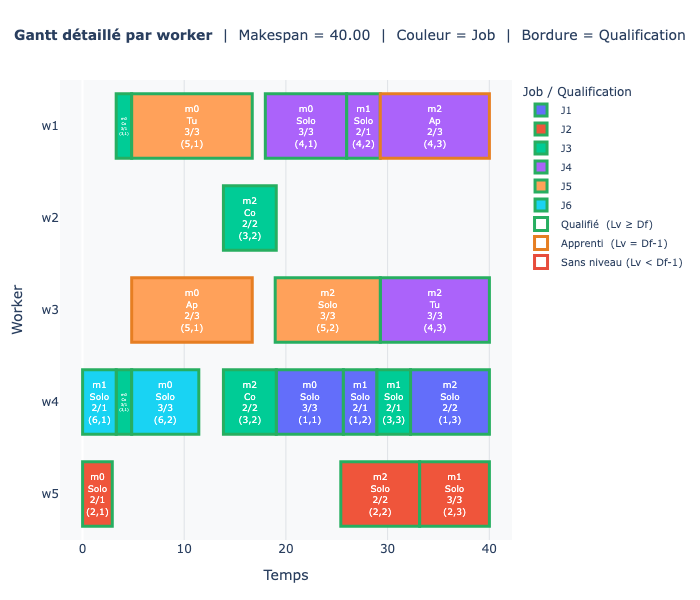

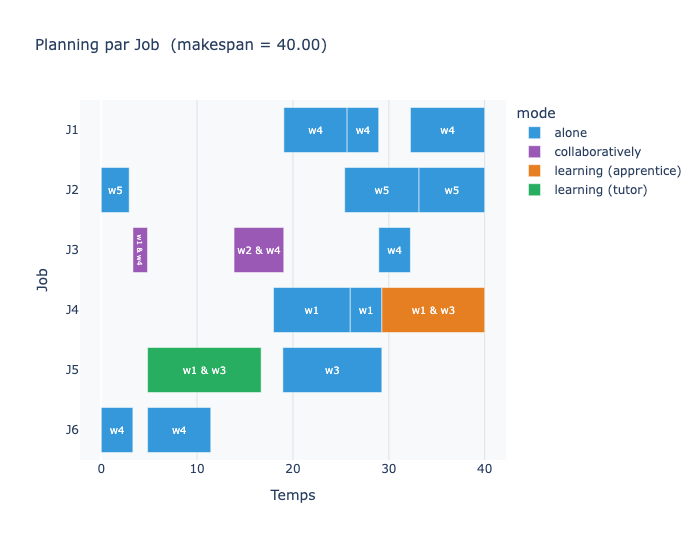

In [201]:
gantt_chart_rich(df_benefit, render="notebook", save_path=None)
gantt_chart_by_job(df_benefit, instance2, color_by="mode", render="notebook", save_path=None, separate_little=True)

In [202]:
s_report_benefit = solution_business_report(s_benefit, instance2, verbose=False)
plot_business_report(s_report_benefit, instance2)

## Lexicographic

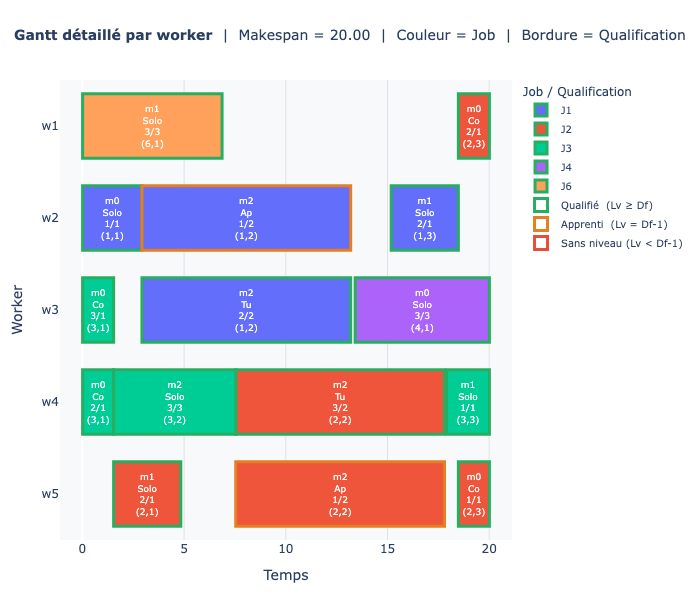

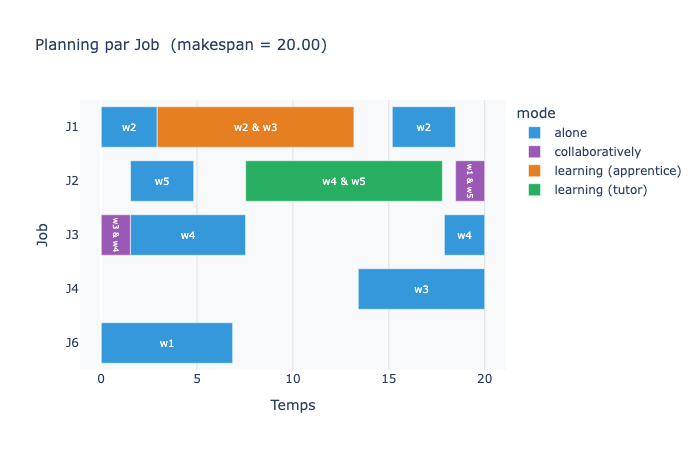

In [184]:
gantt_chart_rich(df_lex, render="notebook", save_path=None)
gantt_chart_by_job(df_lex, instance2, color_by="mode", render="notebook", save_path=None, separate_little=True)

In [187]:
s_report_lex = solution_business_report(s_lex, instance2, verbose=False)
plot_business_report(s_report_lex, instance2, render="html")

In [189]:
sum_benef = s_benefit.get_summary()
sum_lex = s_lex.get_summary()
Solution.plot_comparison([sum_benef, sum_lex], title="Comparaison des solutions (benefit vs lexicographic)")

# III. Expérience comparative — MILP vs Métaheuristiques sur plusieurs instances

## Paramètres de l'expérience

In [282]:
import time
import numpy as np

NB_INST   = 1
NB_SEEDS  = 2
INST_SEEDS = list(range(NB_INST))
ALGO_SEEDS = list(range(NB_SEEDS))
MAX_EVAL  = 100
PATIENCE  = 30   # évaluations sans amélioration avant restart (MLS) ou escalade (VNS)

SCENARIO_PARAMS = dict(
    nb_jobs=6,
    nb_workers=5,
    nb_professions=3,
    nb_tasks_per_profession=3,
    max_nb_operations=4,
    worker_profile="balanced",
    schedule_tightness=0.8,
)
CONSTRAINTS_EXP = {
    "job_with_no_skills": False,
    "constrained_makespan": 30,
    "no_base_worker": False,
    "no_solo_tasks": False,
}
WEIGHTS_EXP = {"profit": 1, "skills": 1, "cognitive_load": 1}

## Génération des instances

In [283]:
instances_exp = []
for seed in INST_SEEDS:
    inst = Instance()
    inst.from_scenario(**SCENARIO_PARAMS, seed=seed)
    instances_exp.append(inst)
    print(f"Instance seed={seed} : {inst.nb_jobs} jobs, {inst.nb_workers} workers")

Instance seed=0 : 6 jobs, 5 workers


## Lancement MILP + métaheuristiques

In [284]:
def build_neighborhoods(gen, nb_job_no_skills=0):
    """Retourne la liste des voisinages à tester — modifier ici pour ajouter/retirer un voisinage."""
    return [
        (SwapOperationNeighborhood(n=5, nb_job_no_skills=nb_job_no_skills), "Swap OSC"),
        (MoveOneOperationNeighborhood(),                                      "Move OSC"),
        (MoveSecondWorkerNeighborhood(gen),                                   "Move SWAC"),
        (MoveJobNeighborhood(n=3), "Move Job"),  # k=1 perturbation moyenne
        (ChangebaseWorkerNeighborhood(nb_job_no_skills=nb_job_no_skills, generator=gen), "Change Base Worker"),
        (multipleNeighborhood_alternating(
            SwapOperationNeighborhood(n=5, nb_job_no_skills=nb_job_no_skills),
            MoveSecondWorkerNeighborhood(gen),
            nb_job_no_skills=nb_job_no_skills,
        ), "Alternating"),
    ]

In [ ]:
instance_setups = []
for inst in instances_exp:
    nb_no_skills = CONSTRAINTS_EXP.get("nb_job_no_skills", 0)
    enc = Encoding_Dicos(inst)
    gen = ChromosomeGenerator(inst, enc, constraints_config=CONSTRAINTS_EXP)
    dec = Decoder(inst, enc, constraints_config=CONSTRAINTS_EXP)
    ev  = Evaluator(dec, WEIGHTS_EXP)
    sel = BestSelector()
    shaking = [
        ShuffleOperationsNeighborhood(n=3, nb_job_no_skills=nb_no_skills),
        ChangebaseWorkerNeighborhood(nb_job_no_skills=nb_no_skills, generator=gen),
    ]
    neighborhoods = build_neighborhoods(gen, nb_job_no_skills=nb_no_skills)
    instance_setups.append((gen, dec, ev, sel, shaking, neighborhoods))

neighborhood_labels = [label for _, label in instance_setups[0][-1]]
all_labels = ["RS"] + [f"{l} (MLS)" for l in neighborhood_labels] + [f"{l} (VNS)" for l in neighborhood_labels]

milp_results = np.empty(NB_INST, dtype=object)

# Pour chaque label, (instance i, seed j) :
all_viewed     = {label: np.empty((NB_INST, NB_SEEDS), dtype=object) for label in all_labels}  # tous les chromosomes visités
best_list      = {label: np.empty((NB_INST, NB_SEEDS), dtype=object) for label in all_labels}  # améliorations successives
best_eval_list = {label: np.empty((NB_INST, NB_SEEDS), dtype=object) for label in all_labels}  # évaluation absolue de chaque amélioration
best           = {label: np.empty((NB_INST, NB_SEEDS), dtype=object) for label in all_labels}  # meilleur chromosome global

In [258]:
# print(best.keys())
# print(type(best["RS"]))
# print((best["RS"].shape))
# print(type(best["RS"][0, 0]))
# print("-----")
# print(all_viewed.keys())
# print(type(all_viewed["RS"]))
# print((all_viewed["RS"].shape))
# print(type(all_viewed["RS"][0, 0]))
# for ii in range(NB_INST):
#     for ss in range(NB_SEEDS):
#         print(f"Instance {ii}, Seed {ss}")
#         for label in all_labels:
#             print(f"{label}: best[{label}][{ii}, {ss}] = {best[label][ii, ss].fitness}")

# #MILP and RS

In [286]:
milp_times = np.empty(NB_INST, dtype=float)
for i, inst in enumerate(instances_exp):
    t0 = time.time()
    milp_results[i] = Model(inst).solve(
        objective="lexicographic", weight=WEIGHTS_EXP,
        priority=[2, 1, 0], constraints_config=CONSTRAINTS_EXP, verbose=False,
    )
    milp_times[i] = time.time() - t0
    print(f"MILP I{i+1} → {milp_results[i].get_summary()['benefit']:.2f}  ({milp_times[i]:.1f}s)")

rs_times = np.empty((NB_INST, NB_SEEDS), dtype=float)
for i, (gen, _, ev, *_rest) in enumerate(instance_setups):
    for j, seed in enumerate(ALGO_SEEDS):
        np.random.seed(seed)
        t0 = time.time()
        av, bl, bel, _ = RandomSearch(gen, ev).run(MAX_EVAL, verbose=False)
        rs_times[i, j]          = time.time() - t0
        all_viewed["RS"][i, j]  = av
        best_list["RS"][i, j]   = bl
        best_eval_list["RS"][i, j] = bel
        best["RS"][i, j]        = bl[-1]
    print(f"RS I{i+1} terminé  (moy {rs_times[i].mean():.1f}s/seed)")


 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
limite MAKESPAN =  30
constrained makespan activated with limit = 30
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 30
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"


Random Search Iterations:  36%|███▌      | 36/100 [00:00<00:00, 350.16it/s]

Optimal solution found with objective value: 314.7698415286801
nObjectives 3
nSolutions 10
et la -> 30
Borne sup makespan: 30
MILP I1 → 314.77  (16.7s)


Random Search Iterations: 100%|██████████| 100/100 [00:00<00:00, 396.46it/s]

RS I1 terminé  (moy 0.3s/seed)


In [324]:
print(best_eval_list["RS"][0, 0])
print(best_eval_list["RS"][0, 1])
print(curves[0])
print(curves[1])

[0, 1, 7, 27]
[0, 1, 4, 31, 34]
[ -1.55711838 101.32175845 101.32175845 101.32175845 101.32175845
 101.32175845 101.32175845 150.9494973  150.9494973  150.9494973
 150.9494973  150.9494973  150.9494973  150.9494973  150.9494973
 150.9494973  150.9494973  150.9494973  150.9494973  150.9494973
 150.9494973  150.9494973  150.9494973  150.9494973  150.9494973
 150.9494973  150.9494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.7494973
 151.7494973  151.7494973  151.7494973  151.7494973  151.

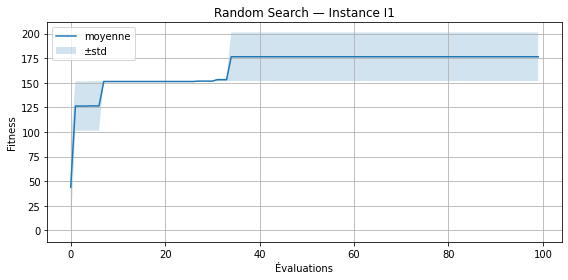

In [323]:
for i in range(NB_INST):
    curves = []
    for j in range(NB_SEEDS):
        fitness_curve = np.maximum.accumulate([c.fitness for c in all_viewed["RS"][i, j]])
        curves.append(fitness_curve)

    n = min(len(c) for c in curves)
    mean_curve = np.mean([c[:n] for c in curves], axis=0)
    std_curve  = np.std( [c[:n] for c in curves], axis=0)
    t = np.arange(n)

    plt.figure(figsize=(8, 4))
    plt.plot(t, mean_curve, label="moyenne")
    plt.fill_between(t, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2, label="±std")
    plt.title(f"Random Search — Instance I{i+1}")
    plt.xlabel("Évaluations")
    plt.ylabel("Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [288]:
milp_times, rs_times

(array([16.65433979]), array([[0.30082202, 0.25491095]]))

### MLS

In [289]:
mls_times = {label: np.empty((NB_INST, NB_SEEDS), dtype=float) for label in all_labels if "(MLS)" in label}

for i, (gen, _, ev, sel, shaking, neighborhoods) in enumerate(instance_setups):
    for j, seed in enumerate(ALGO_SEEDS):
        np.random.seed(seed)
        for neighborhood, label in neighborhoods:
            t0 = time.time()
            av, bl, bel, b = MultipleLocalSearch(gen, ev, neighborhood, sel).run(MAX_EVAL, patience=PATIENCE)
            mls_times[f"{label} (MLS)"][i, j]      = time.time() - t0
            all_viewed[f"{label} (MLS)"][i, j]     = av
            best_list[f"{label} (MLS)"][i, j]      = bl
            best_eval_list[f"{label} (MLS)"][i, j] = bel
            best[f"{label} (MLS)"][i, j]           = b
    print(f"MLS I{i+1} terminé  (moy {mls_times[f'{label} (MLS)'][i].mean():.1f}s/seed)")

MLS I1 terminé  (moy 0.1s/seed)


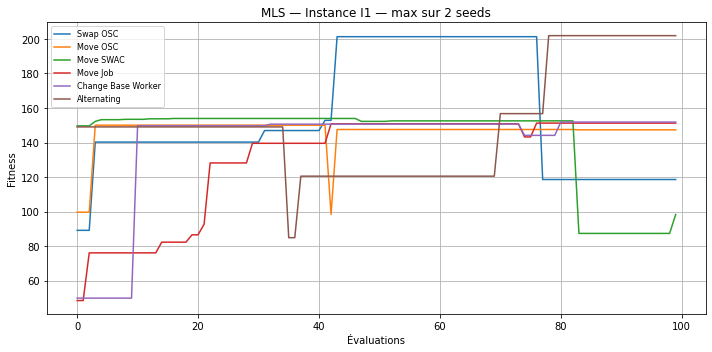

In [ ]:
for i in range(NB_INST):
    plt.figure(figsize=(10, 5))

    for label in [l for l in all_labels if "(MLS)" in l]:
        curves = []
        for j in range(NB_SEEDS):
            evals = best_eval_list[label][i, j]
            fitnesses = [c.fitness for c in best_list[label][i, j]]
            curve = np.zeros(MAX_EVAL)
            current_best = best_list[label][i, j][0].fitness
            k = 0
            for t in range(MAX_EVAL):
                while k < len(evals) and evals[k] <= t:
                    current_best = fitnesses[k]
                    k += 1
                curve[t] = current_best
            curves.append(curve)

        n = min(len(c) for c in curves)
        max_curve = np.max([c[:n] for c in curves], axis=0)
        t = np.arange(n)

        plt.plot(t, max_curve, label=f"{label.replace(' (MLS)', '')}")

    plt.title(f"MLS — Instance I{i+1} — max sur {NB_SEEDS} seeds")
    plt.xlabel("Évaluations")
    plt.ylabel("Fitness")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [298]:
for i in range(NB_INST):
    print(f"Instance I{i+1}")
    for label in [l for l in all_labels if "(MLS)" in l]:
        fitnesses = [best[label][i, j].fitness for j in range(NB_SEEDS)]
        print(f"  {label.replace(' (MLS)', ''):25s} → max={max(fitnesses):.2f}  mean={np.mean(fitnesses):.2f}  std={np.std(fitnesses):.2f}")
    print()

Instance I1
  Swap OSC                  → max=201.33  mean=170.79  std=30.54
  Move OSC                  → max=150.06  mean=124.22  std=25.84
  Move SWAC                 → max=153.95  mean=153.25  std=0.70
  Move Job                  → max=151.25  mean=151.15  std=0.10
  Change Base Worker        → max=151.86  mean=148.50  std=3.35
  Alternating               → max=201.93  mean=179.34  std=22.59



In [301]:
x = np.random.randint(0, 100, size=20)

In [304]:
print(x)
print(np.maximum.accumulate(x))

[19 32 11 51 87 85 64 76 60  8 39 84 97 18  3 46 40 31 95 42]
[19 32 32 51 87 87 87 87 87 87 87 87 97 97 97 97 97 97 97 97]


In [238]:
for k in mls_times.keys():
    print(k)
    print(mls_times[k], "\n")

Swap OSC (MLS)
[[2.60089183 2.06442022 2.0937717 ]
 [1.93492913 1.80199194 1.84435034]
 [2.09658694 2.18443179 2.11580372]] 

Move OSC (MLS)
[[5.23203421 5.15825391 5.47505689]
 [4.00570798 4.24209833 4.0971849 ]
 [5.9266901  6.11854935 5.96519089]] 

Move SWAC (MLS)
[[0.02725792 0.0240469  0.0295608 ]
 [0.01873994 0.01638699 0.01796293]
 [0.04736686 0.01972985 0.18451595]] 

Move Job (MLS)
[[1.36751485 1.26377201 1.35433698]
 [1.19679093 1.29333878 1.19558883]
 [1.82048988 1.46623325 1.43578982]] 

Change Base Worker (MLS)
[[15.92170906 13.02418804 13.59307504]
 [10.80738187 11.93248296 10.39473987]
 [ 9.38770318  9.39958382  9.06683183]] 

Alternating (MLS)
[[0.0781939  0.08745694 0.07987809]
 [0.03084183 0.06722713 0.06059074]
 [0.09455013 0.07867694 0.16958785]] 



### VNS

In [186]:
vns_times = {label: np.empty((NB_INST, NB_SEEDS), dtype=float) for label in [l for l in all_labels if "(VNS)" in l]}

for i, (gen, _, ev, sel, shaking, neighborhoods) in enumerate(instance_setups):
    for j, seed in enumerate(ALGO_SEEDS):
        np.random.seed(seed)
        for neighborhood, label in neighborhoods:
            t0 = time.time()
            av, bl = VNS(gen, ev, [neighborhood]+shaking, sel, ls_max_iter=MAX_ITER).run(MAX_ITER_VNS, verbose=False)
            vns_times[f"{label} (VNS)"][i, j] = time.time() - t0
            best[f"{label} (VNS)"][i, j]       = bl[-1]
            all_viewed[f"{label} (VNS)"][i, j] = av
    print(f"VNS I{i+1} terminé  (ex: {label} moy {vns_times[f'{label} (VNS)'][i].mean():.1f}s/seed)")

VNS Iterations:   0%|          | 0/5 [00:00<?, ?it/s]

VNS I1 terminé  (ex: Alternating moy 5.1s/seed)


VNS Iterations:   0%|          | 0/5 [00:00<?, ?it/s]

VNS I2 terminé  (ex: Alternating moy 3.7s/seed)


VNS Iterations: 100%|██████████| 5/5 [00:06<00:00,  1.21s/it]

VNS I3 terminé  (ex: Alternating moy 5.8s/seed)


In [188]:
for k in vns_times.keys():
    print(k)
    print(vns_times[k], "\n")

Swap OSC (VNS)
[[7.88829303 6.88601589 8.25809312]
 [7.77875996 7.04019618 7.9094162 ]
 [6.80267525 9.08613706 8.40883112]] 

Move OSC (VNS)
[[26.99410605 16.91737509 20.45584083]
 [20.81930804 12.29908609 20.48731494]
 [23.181705   22.25252199 21.91249084]] 

Move SWAC (VNS)
[[1.327986   2.43887901 1.26361585]
 [1.09655404 1.17093992 1.18870997]
 [2.48871899 1.64224839 1.67928028]] 

Move Job (VNS)
[[8.06902981 7.88627315 6.06193686]
 [5.22952676 8.0455339  5.53944921]
 [6.73951697 7.271595   6.26011205]] 

Change Base Worker (VNS)
[[55.5018189  44.95955729 72.66128778]
 [39.15719509 50.68685389 34.59664917]
 [28.28908014 42.52010393 42.88466096]] 

Alternating (VNS)
[[5.51870584 6.69996595 3.12794495]
 [4.86533809 3.11256695 3.15344   ]
 [7.12389588 4.10132408 6.03526926]] 



## fonction pour passer de liste de chromosome a liste de nombre

In [239]:
def to_fitness(arr):
    result = np.empty(arr.shape, dtype=object)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            result[i, j] = np.array([c.fitness for c in arr[i, j]])
    return result

def to_objectives(arr):
    result = np.empty(arr.shape, dtype=object)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            result[i, j] = np.array([c.objectives for c in arr[i, j]])
    return result

def last_values(arr, i):
    return np.array([arr[i, j][-1] for j in range(arr.shape[1])])

In [230]:
len(all_viewed["RS"][0, 0]), (best["RS"][0, 0]) 

(100, <metaheuristic_approach.Chromosome at 0x7ff5613db0d0>)

In [240]:
viewed_fitness = {label: to_fitness(all_viewed[label]) for label in all_labels}
# all_best_fitness = {label: to_fitness(best[label]) for label in all_labels}

# viewed_objectives = {label: to_objectives(all_viewed[label]) for label in all_labels}


In [241]:
for i in range(NB_INST):
    print(f"Instance {i} :")
    for label in all_labels:
        last = last_values(viewed_fitness[label], i)
        print(f"  {label} : {last}")

Instance 0 :
  RS : [98.52845532 79.94856583 47.52068172]
  Swap OSC (MLS) : [154.6494973  143.05619417 150.74915981]
  Move OSC (MLS) : [154.6494973  150.4494973  201.62695991]
  Move SWAC (MLS) : [139.07596719  -1.95711838 109.92161319]
  Move Job (MLS) : [200.72695991 187.45376729 201.22695991]
  Change Base Worker (MLS) : [121.42161319 167.8990758  203.82695991]
  Alternating (MLS) : [ 91.74856583  -2.25711838 142.17596719]
  Swap OSC (VNS) : [154.94915981 150.6494973  149.8494973 ]
  Move OSC (VNS) : [199.72695991 149.95619417 156.9494973 ]
  Move SWAC (VNS) : [153.8494973   96.87873157 148.25619417]
  Move Job (VNS) : [199.22695991 199.02695991 152.2494973 ]
  Change Base Worker (VNS) : [203.82695991 204.22695991 204.82695991]
  Alternating (VNS) : [153.2494973  156.2494973  203.12695991]
Instance 1 :
  RS : [ 69.83148192 127.68722898 128.78722898]
  Swap OSC (MLS) : [119.32762535 115.88858421 126.28722898]
  Move OSC (MLS) : [129.48722898 128.38722898 126.08722898]
  Move SWAC (

In [236]:
viewed_fitness["Swap OSC (MLS)"][0,0].shape

(500,)

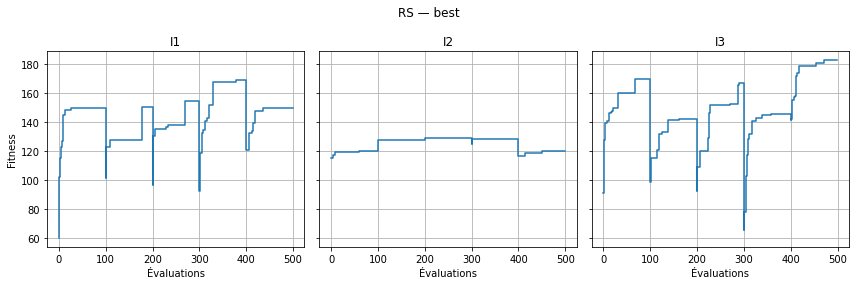

In [242]:
def plot_evolution(fitness_arr, label="", mode="all_viewed"):
    fig, axes = plt.subplots(1, NB_INST, figsize=(4*NB_INST, 4), sharey=True)

    for i, ax in enumerate(axes):
        curves = [fitness_arr[i, j] for j in range(NB_SEEDS)]
        n = min(len(c) for c in curves)
        mean_curve = np.mean([c[:n] for c in curves], axis=0)

        if mode == "best":
            ax.step(range(n), mean_curve, where="post")
        else:
            ax.plot(mean_curve)

        ax.set_title(f"I{i+1}")
        ax.set_xlabel("Évaluations")
        ax.grid()
        if i == 0:
            ax.set_ylabel("Fitness")

    plt.suptitle(label)
    plt.tight_layout()
    plt.show()


plot_evolution(viewed_fitness["Swap OSC (MLS)"],          label="RS — best",       mode="best")
# plot_evolution(bes["RS"],          label="RS — best",       mode="best")
# plot_evolution(viewed_fitness["RS"],        label="RS — all_viewed", mode="all_viewed")
# plot_evolution(best_fitness["Swap OSC (MLS)"], label="MLS Swap OSC", mode="best")

In [213]:
viewed_fitness["RS"][0, 0][-1], viewed_fitness["RS"][0, 1][-1], viewed_fitness["RS"][0, 2][-1]

(98.52845531989644, 79.94856583278678, 47.520681722083005)

In [ ]:
for label in all_labels:
    print(f"{label}:   {viewed_fitness[label][0, 0]})")

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [143]:
for ii in range(NB_INST):
    for ss in range(NB_SEEDS):
        for label in all_labels:
            c = best[label][ii, ss]
            # print(f"Chromosome: {c.fitness}, --> {c.objectives}")
            row, ok = validate_model_solution(
                instance=instances_exp[ii],
                solution=instance_setups[ii][1].decode_solution(c),
                constraints_config=CONSTRAINTS_EXP,
            )
            print(f"Instance {ii}, seed {ss}, méthode {label} - Result: {ok}\n")
            if not ok:
                print("Solution is not valid!")
            # display(pd.DataFrame([row]))

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Instance 0, seed 0, méthode RS - Result: True

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Instance 0, seed 0, méthode Swap OSC (MLS) - Result: True

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Instance 0, seed 0, méthode Move OSC (MLS) - Result: True

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Instance 0, seed 0, méthode Move SWAC (MLS) - Result: True

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Instance 0, seed 0, méthode Move Job (MLS) - Result: True

Exécution du test solution_valide...
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Instance 0, seed 0, méthode Change Base Worker (MLS) - R

### MLS

In [244]:
all_viewed.keys()

dict_keys(['RS', 'Swap OSC (MLS)', 'Move OSC (MLS)', 'Move SWAC (MLS)', 'Move Job (MLS)', 'Change Base Worker (MLS)', 'Alternating (MLS)', 'Swap OSC (VNS)', 'Move OSC (VNS)', 'Move SWAC (VNS)', 'Move Job (VNS)', 'Change Base Worker (VNS)', 'Alternating (VNS)'])

In [247]:
base_labels

['Swap OSC',
 'Move OSC',
 'Move SWAC',
 'Move Job',
 'Change Base Worker',
 'Alternating']

skills 2.0
Instance I1 - MILP objectives: {'0': 314.7698415286801, '1': 2.0, '2': -39.20000000000001}
skills 0.0
Instance I2 - MILP objectives: {'0': 207.58722898000963, '1': 0.0, '2': -0.0}
skills 1.0
Instance I3 - MILP objectives: {'0': 344.66468850950685, '1': 1.0, '2': -32.0}
Instance I1 - Base: Swap OSC (MLS)
Instance I1 - Base: Move OSC (MLS)
Instance I1 - Base: Move SWAC (MLS)
Instance I1 - Base: Move Job (MLS)
Instance I1 - Base: Change Base Worker (MLS)
Instance I1 - Base: Alternating (MLS)


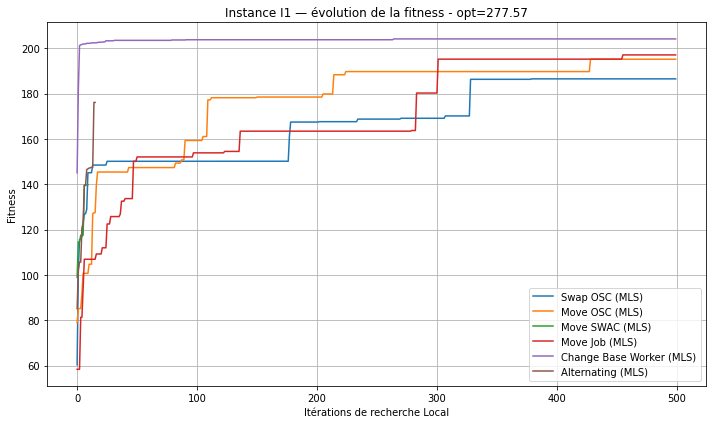

Instance I2 - Base: Swap OSC (MLS)
Instance I2 - Base: Move OSC (MLS)
Instance I2 - Base: Move SWAC (MLS)
Instance I2 - Base: Move Job (MLS)
Instance I2 - Base: Change Base Worker (MLS)
Instance I2 - Base: Alternating (MLS)


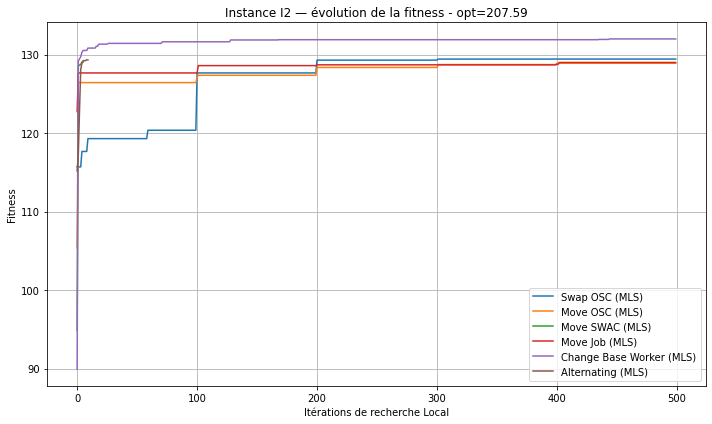

Instance I3 - Base: Swap OSC (MLS)
Instance I3 - Base: Move OSC (MLS)
Instance I3 - Base: Move SWAC (MLS)
Instance I3 - Base: Move Job (MLS)
Instance I3 - Base: Change Base Worker (MLS)
Instance I3 - Base: Alternating (MLS)


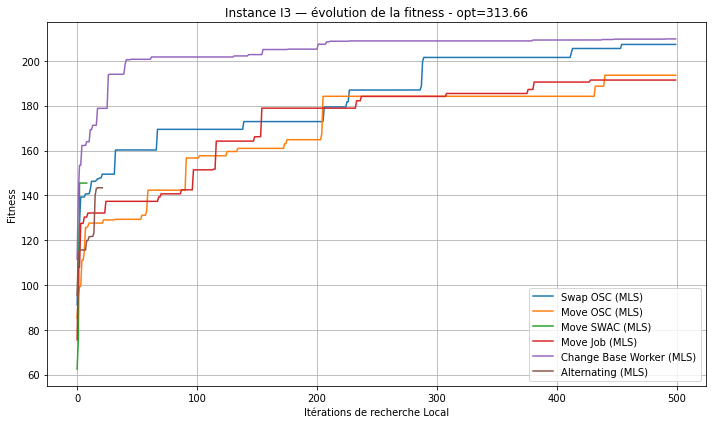

In [252]:
mls_keys = [key for key in best.keys() if "(MLS)" in key]

objs_per_instance = []
for i in range(NB_INST):
    objs = milp_results[i].compute_objective_values()
    print(f"Instance I{i+1} - MILP objectives: {objs}")
    objs_per_instance.append(objs["0"] + objs["1"] + objs["2"])

for i in range(NB_INST):
    plt.figure(figsize=(10, 6))

    for base in mls_keys:
        print(f"Instance I{i+1} - Base: {base}")
        curves = [
            np.maximum.accumulate([
                c.fitness for c in all_viewed[f"{base}"][i, j]
            ])
            for j in range(NB_SEEDS)
        ]

        n = min(map(len, curves))
        mean_curve = np.mean([c[:n] for c in curves], axis=0)

        plt.plot(mean_curve, label=base)

    plt.title(f"Instance I{i+1} — évolution de la fitness - opt={objs_per_instance[i]:.2f}")
    plt.xlabel("Itérations de recherche Local")
    plt.ylabel("Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### VNS

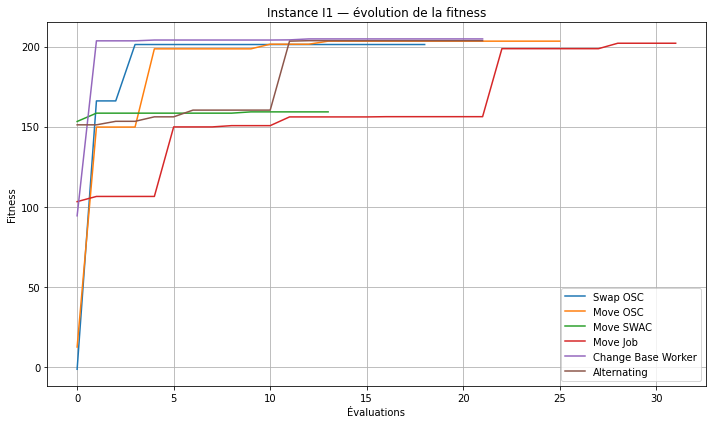

In [151]:
base_labels = [l.replace(" (VNS)", "") for l in all_labels if "(VNS)" in l]

for i in range(NB_INST):
    plt.figure(figsize=(10, 6))

    for base in base_labels:
        curves = [
            np.maximum.accumulate([
                c.fitness for c in all_viewed[f"{base} (VNS)"][i, j]
            ])
            for j in range(NB_SEEDS)
        ]

        n = min(map(len, curves))
        mean_curve = np.mean([c[:n] for c in curves], axis=0)

        plt.plot(mean_curve, label=base)

    plt.title(f"Instance I{i+1} — évolution de la fitness")
    plt.xlabel("Évaluations")
    plt.ylabel("Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

skills 2.0


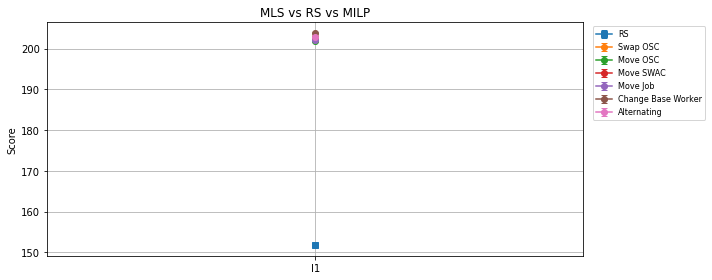

In [144]:
import matplotlib.pyplot as plt
import numpy as np

def milp_score(sol):
    obj = sol.compute_objective_values()
    return obj["0"] + obj["1"] + obj["2"]  # benefit + skills - cognitive_load

inst_labels  = [f"I{i+1}" for i in range(NB_INST)]
x = np.arange(NB_INST)

milp_scores = [milp_score(milp_results[i]) for i in range(NB_INST)]
rs_scores   = [[best["RS"][i,j].fitness for j in range(NB_SEEDS)] for i in range(NB_INST)]

fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(x, milp_scores, "k--o", label="MILP")
ax.errorbar(x, [np.mean(s) for s in rs_scores], yerr=[np.std(s) for s in rs_scores],
            fmt="-s", label="RS", capsize=3)

for label in [l for l in all_labels if "(MLS)" in l]:
    scores = [[best[label][i,j].fitness for j in range(NB_SEEDS)] for i in range(NB_INST)]
    ax.errorbar(x, [np.mean(s) for s in scores], yerr=[np.std(s) for s in scores],
                fmt="-o", label=label.replace(" (MLS)", ""), capsize=3)

ax.set_xticks(x); ax.set_xticklabels(inst_labels)
ax.set_ylabel("Score"); ax.set_title("MLS vs RS vs MILP")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.grid(True); plt.show()

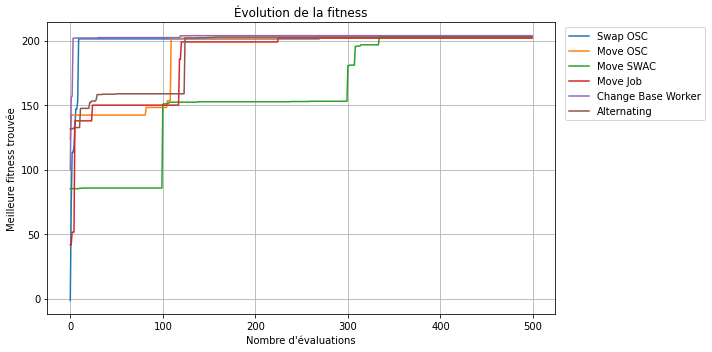

In [145]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

labels_to_plot = [l for l in all_labels if "(MLS)" in l]

for label in labels_to_plot:
    all_curves = []

    for i in range(NB_INST):
        for j in range(NB_SEEDS):
            best_so_far = -float("inf")
            curve = []

            for c in all_viewed[label][i, j]:
                best_so_far = max(best_so_far, c.fitness)
                curve.append(best_so_far)

            all_curves.append(curve)

    min_len = min(len(c) for c in all_curves)

    mat = np.array([
        c[:min_len]
        for c in all_curves
    ])

    x = np.arange(min_len)
    mean = mat.mean(axis=0)
    std = mat.std(axis=0)

    ax.plot(
        x,
        mean,
        label=label.replace(" (MLS)", "")
    )

    ax.fill_between(
        x,
        mean - std,
        mean + std,
        alpha=0.15
    )

ax.set_xlabel("Nombre d'évaluations")
ax.set_ylabel("Meilleure fitness trouvée")
ax.set_title("Évolution de la fitness")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.show()

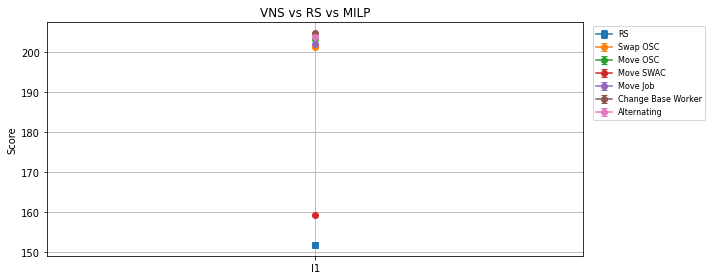

In [90]:
fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(x, milp_scores, "k--o", label="MILP")
ax.errorbar(x, [np.mean(s) for s in rs_scores], yerr=[np.std(s) for s in rs_scores],
            fmt="-s", label="RS", capsize=3)

for label in [l for l in all_labels if "(VNS)" in l]:
    scores = [[best[label][i,j].fitness for j in range(NB_SEEDS)] for i in range(NB_INST)]
    ax.errorbar(x, [np.mean(s) for s in scores], yerr=[np.std(s) for s in scores],
                fmt="-o", label=label.replace(" (VNS)", ""), capsize=3)

ax.set_xticks(x); ax.set_xticklabels(inst_labels)
ax.set_ylabel("Score"); ax.set_title("VNS vs RS vs MILP")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.grid(True); plt.show()

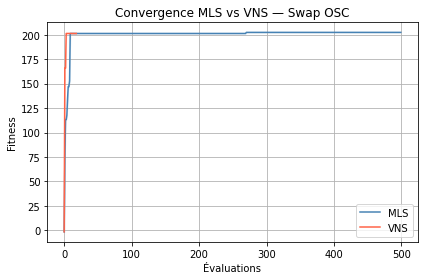

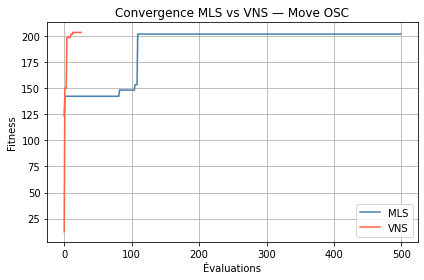

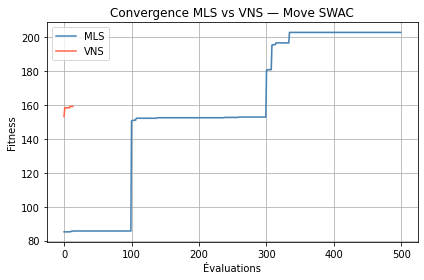

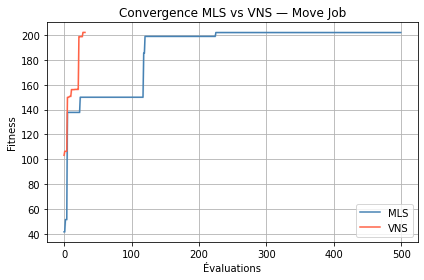

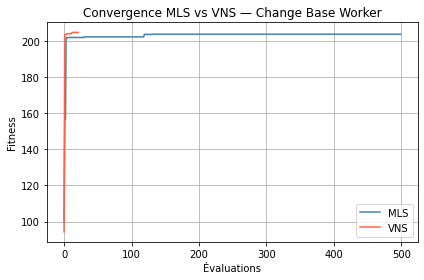

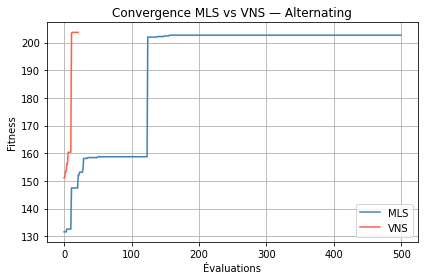

In [91]:
base_labels = [l.replace(" (MLS)", "") for l in all_labels if "(MLS)" in l]

for base in base_labels:

    # Une nouvelle figure pour chaque graphique
    fig, ax = plt.subplots(figsize=(6, 4))

    for algo, color in [("MLS", "steelblue"), ("VNS", "tomato")]:
        all_curves = []

        for i in range(NB_INST):
            for j in range(NB_SEEDS):
                best_so_far = -float("inf")
                curve = []

                for c in all_viewed[f"{base} ({algo})"][i, j]:
                    if c.fitness > best_so_far:
                        best_so_far = c.fitness

                    curve.append(best_so_far)

                all_curves.append(curve)

        # Toutes les courbes doivent avoir la même longueur
        min_len = min(len(c) for c in all_curves)

        mat = np.array([
            c[:min_len]
            for c in all_curves
        ])

        x = np.arange(min_len)

        # Moyenne
        ax.plot(
            x,
            mat.mean(axis=0),
            color=color,
            label=algo
        )

        # Min / Max
        ax.fill_between(
            x,
            mat.min(axis=0),
            mat.max(axis=0),
            alpha=0.15,
            color=color
        )

    ax.set_title(f"Convergence MLS vs VNS — {base}")
    ax.set_xlabel("Évaluations")
    ax.set_ylabel("Fitness")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

## Tableau de synthèse

In [228]:
rows = []
for idx, entry in enumerate(results_exp):
    milp_sum    = entry["milp"]["summary"]
    milp_profit = milp_sum["benefit"]
    milp_time   = entry["milp"]["time"]

    row = {
        "Instance":        f"I{idx+1} (seed={entry['seed']})",
        "MILP profit":     round(milp_profit, 2),
        "MILP skills":     round(milp_sum["skill_gain"], 2),
        "MILP time (s)":   round(milp_time, 1),
    }

    for label, meta_res in entry["meta"].items():
        # On utilise le summary de la solution décodée (mêmes métriques que le MILP)
        best_summary = meta_res["best"]["summary"]
        best_profit  = best_summary["benefit"]
        best_skills  = best_summary["skill_gain"]
        gap = (milp_profit - best_profit) / milp_profit * 100 if milp_profit > 0 else 0

        row[f"{label} profit"] = round(best_profit, 2)
        row[f"{label} skills"] = round(best_skills, 2)
        row[f"{label} gap%"]   = round(gap, 1)

    rows.append(row)

df_results = pd.DataFrame(rows)
display(df_results)

,Instance,MILP profit,MILP skills,MILP time (s),Swap OSC profit,Swap OSC skills,Swap OSC gap%,Move OSC profit,Move OSC skills,Move OSC gap%,Move SWAC profit,Move SWAC skills,Move SWAC gap%,Change Base Worker profit,Change Base Worker skills,Change Base Worker gap%,Alternating profit,Alternating skills,Alternating gap%
0,I1 (seed=0),314.77,2.0,3.2,278.43,1.0,11.5,314.77,1.5,0.0,278.43,1.0,11.5,314.77,1.5,0.0,278.43,1.0,11.5
1,I2 (seed=1),207.59,0.0,1.0,207.59,0.0,0.0,207.59,0.0,0.0,207.59,0.0,0.0,207.59,0.0,0.0,207.59,0.0,0.0
2,I3 (seed=2),344.66,1.5,4.7,344.66,0.0,0.0,344.66,0.0,0.0,292.29,0.0,15.2,344.66,0.0,0.0,344.66,0.0,0.0
3,I4 (seed=3),306.92,1.0,1.1,306.92,1.0,0.0,306.92,1.0,0.0,306.92,1.0,0.0,306.92,1.0,0.0,306.92,1.0,0.0
4,I5 (seed=4),204.85,2.0,24.5,195.52,2.0,4.6,195.52,1.5,4.6,170.18,1.5,16.9,195.52,2.0,4.6,195.52,2.0,4.6


## Comparaison visuelle meilleure métaheuristique vs MILP

In [229]:
for idx, entry in enumerate(results_exp):
    milp_summary = entry["milp"]["summary"]

    # Meilleur voisinage sur cette instance (par fitness)
    best_label = max(entry["meta"], key=lambda l: entry["meta"][l]["best"]["fitness"])
    best_meta_summary = entry["meta"][best_label]["best"]["summary"]

    milp_summary["label"] = f"MILP (s={entry['seed']})"
    best_meta_summary["label"] = f"{best_label} (s={entry['seed']})"

    Solution.plot_comparison(
        [milp_summary, best_meta_summary],
        title=f"Instance {idx+1} (seed={entry['seed']}) — MILP vs {best_label}",
    )

## Moyenne et écart-type de la fitness par voisinage

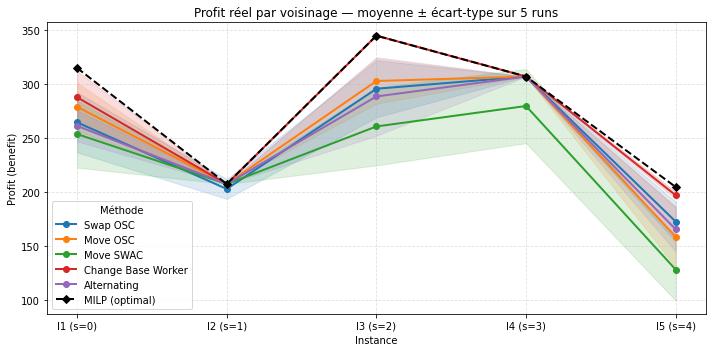

In [231]:
import matplotlib.pyplot as plt
import numpy as np

instance_labels     = [f"I{i+1} (s={entry['seed']})" for i, entry in enumerate(results_exp)]
neighborhood_labels = list(results_exp[0]["meta"].keys())
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(10, 5))

for n_idx, label in enumerate(neighborhood_labels):
    color = colors[n_idx % len(colors)]
    x = np.arange(len(instance_labels))

    means, stds = [], []
    for entry in results_exp:
        profits = [r["summary"]["benefit"] for r in entry["meta"][label]["runs"]]
        means.append(np.mean(profits))
        stds.append(np.std(profits))

    means = np.array(means)
    stds  = np.array(stds)

    ax.plot(x, means, marker="o", color=color, linewidth=2, label=label)
    ax.fill_between(x, means - stds, means + stds, color=color, alpha=0.15)

# MILP référence
milp_profits = [entry["milp"]["summary"]["benefit"] for entry in results_exp]
ax.plot(x, milp_profits, marker="D", color="black", linewidth=2,
        linestyle="--", label="MILP (optimal)")

ax.set_xticks(x)
ax.set_xticklabels(instance_labels)
ax.set_xlabel("Instance")
ax.set_ylabel("Profit (benefit)")
ax.set_title(f"Profit réel par voisinage — moyenne ± écart-type sur {NB_RUNS_META} runs")
ax.legend(title="Méthode")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# IV. Comparaison MLS vs VNS

In [6]:
# ======================================================
# PARAMÈTRES — modifier ici uniquement
# ======================================================
NB_RESTARTS   = 5    # nombre de restarts pour MLS (= NB_RUNS_META pour être comparable)
MAX_ITER_MLS  = 200  # itérations max par restart (MLS et LS interne du VNS)
MAX_ITER_VNS  = 50   # itérations externes du VNS (chaque iter = shaking + LS interne)

print(f"NB_RESTARTS  = {NB_RESTARTS}")
print(f"MAX_ITER_MLS = {MAX_ITER_MLS}")
print(f"MAX_ITER_VNS = {MAX_ITER_VNS}")

NB_RESTARTS  = 5
MAX_ITER_MLS = 200
MAX_ITER_VNS = 50


In [7]:
results_mls_vns = []  # une entrée par instance

for idx, inst in enumerate(instances_exp):
    seed = SEEDS_EXP[idx]
    print(f"\n{'='*50}")
    print(f"  Instance {idx+1}/{NB_INSTANCES_EXP}  (seed={seed})")
    print(f"{'='*50}")

    entry = {"seed": seed, "mls": {}, "vns": {}}

    enc_e  = Encoding_Dicos(inst)
    gen_e  = ChromosomeGenerator(inst, enc_e, constraints_config=CONSTRAINTS_EXP)
    dec_e  = Decoder(inst, enc_e, constraints_config=CONSTRAINTS_EXP)
    eval_e = Evaluator(dec_e, WEIGHTS_EXP)
    sel_e  = BestSelector()
    print(enc_e.op_to_id)

    # voisinage de base commun aux deux méthodes
    n_base = MoveSecondWorkerNeighborhood(gen_e)

    # voisinages de shaking pour le VNS, du plus petit au plus grand
    neighborhoods_vns = [
        n_base,                                                    # [0] base (LS interne)
        SwapOperationNeighborhood(n=3),                            # k=0 perturbation faible
        MoveJobNeighborhood(n=3),                                # k=1 perturbation moyenne
        ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen_e),  # k=2 perturbation forte
    ]

    # ── MLS ───────────────────────────────────────────────
    t0 = time.time()
    mls = MultipleLocalSearch(gen_e, eval_e, n_base, sel_e)
    best_list_mls, best_mls = mls.run(NB_RESTARTS, MAX_ITER_MLS, verbose=False)
    t_mls = time.time() - t0

    entry["mls"] = {
        "best_list": best_list_mls,
        "best":      best_mls,
        "runs":      [{"fitness": c.fitness, "objectives": c.objectives} for c in best_list_mls],
        "time":      t_mls,
    }
    print(f"  MLS → best_fitness={best_mls.fitness:.4f}  ({t_mls:.1f}s, {NB_RESTARTS} restarts)")

    # ── VNS ───────────────────────────────────────────────
    t0 = time.time()
    vns = VNS(gen_e, eval_e, neighborhoods_vns, sel_e, ls_max_iter=MAX_ITER_MLS)
    _, best_list_vns = vns.run(MAX_ITER_VNS, verbose=False)
    best_vns = best_list_vns[-1]
    t_vns = time.time() - t0

    entry["vns"] = {
        "best_list": best_list_vns,
        "best":      best_vns,
        "time":      t_vns,
    }
    print(f"  VNS → best_fitness={best_vns.fitness:.4f}  ({t_vns:.1f}s, {MAX_ITER_VNS} iter externes)")

    results_mls_vns.append(entry)

print("\n✓ Expérience terminée.")

NameError: name 'instances_exp' is not defined

In [ ]:
instance_labels = [f"I{i+1} (s={e['seed']})" for i, e in enumerate(results_mls_vns)]
x = np.arange(len(instance_labels))
objectives     = ["benefit", "skill_gain", "cognitive_load"]
obj_titles     = ["Benefit", "Skills", "Cognitive Load"]
colors         = {"MLS": "steelblue", "VNS": "tomato", "MILP": "black"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, obj, title in zip(axes, objectives, obj_titles):

    # MLS — moyenne ± std sur les restarts
    mls_means, mls_stds = [], []
    for entry in results_mls_vns:
        vals = [c.objectives[objectives.index(obj)] if c.objectives is not None else 0
                for c in entry["mls"]["best_list"]]
        mls_means.append(np.mean(vals))
        mls_stds.append(np.std(vals))
    mls_means = np.array(mls_means)
    mls_stds  = np.array(mls_stds)

    ax.plot(x, mls_means, marker="o", color=colors["MLS"], linewidth=2, label="MLS")
    ax.fill_between(x, mls_means - mls_stds, mls_means + mls_stds,
                    color=colors["MLS"], alpha=0.15)

    # VNS — une seule trajectoire par instance (pas de runs multiples)
    vns_vals = []
    for entry in results_mls_vns:
        best = entry["vns"]["best"]
        vns_vals.append(best.objectives[objectives.index(obj)] if best.objectives is not None else 0)
    ax.plot(x, vns_vals, marker="s", color=colors["VNS"], linewidth=2, label="VNS")

    # MILP — référence
    milp_vals = [entry["milp"]["summary"][obj] for entry in results_exp]
    ax.plot(x, milp_vals, marker="D", color=colors["MILP"], linewidth=2,
            linestyle="--", label="MILP")

    ax.set_xticks(x)
    ax.set_xticklabels(instance_labels, rotation=15)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Valeur objectif")
axes[0].legend(title="Méthode")
fig.suptitle(f"MLS ({NB_RESTARTS} restarts) vs VNS ({MAX_ITER_VNS} iter) vs MILP — {MAX_ITER_MLS} iter LS interne")
plt.tight_layout()
plt.show()

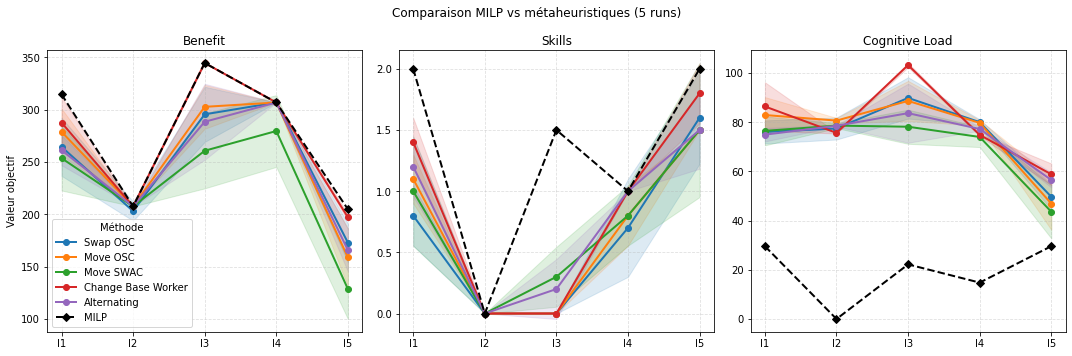

In [233]:
import matplotlib.pyplot as plt
import numpy as np

instance_labels     = [f"I{i+1}" for i, entry in enumerate(results_exp)]
neighborhood_labels = list(results_exp[0]["meta"].keys())
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
x = np.arange(len(instance_labels))

objectives = ["benefit", "skill_gain", "cognitive_load"]
titles     = ["Benefit", "Skills", "Cognitive Load"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, obj, title in zip(axes, objectives, titles):

    for n_idx, label in enumerate(neighborhood_labels):
        color = colors[n_idx % len(colors)]
        means, stds = [], []
        for entry in results_exp:
            vals = [r["summary"][obj] for r in entry["meta"][label]["runs"]]
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        means, stds = np.array(means), np.array(stds)
        ax.plot(x, means, marker="o", color=color, linewidth=2, label=label)
        ax.fill_between(x, means - stds, means + stds, color=color, alpha=0.15)

    milp_vals = [entry["milp"]["summary"][obj] for entry in results_exp]
    ax.plot(x, milp_vals, marker="D", color="black", linewidth=2,
            linestyle="--", label="MILP")

    ax.set_xticks(x)
    ax.set_xticklabels(instance_labels)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Valeur objectif")
axes[0].legend(title="Méthode")
fig.suptitle(f"Comparaison MILP vs métaheuristiques ({NB_RUNS_META} runs)")
plt.tight_layout()
plt.show()